# DAY 1 — 배터리 수명 예측 모델 전략 수립

**울산 3반 이웅희 | 개인 과제 | 2026-10-01**

과제 기준에 따라 Batch 1·2·3을 각각 분석하고 비교한다. 첫 100사이클 정보를 이용해
최종 `cycle_life`를 예측하는 회귀 전략을 수립한다. 질문 3은 Welch t-test를 중심으로
정확 순열검정을 보완한다. 이 노트북은 EDA와 전략 수립을 다루며 모델 성능은 측정하지 않는다.

원본 셀 139개를 보존한다. `cycle_life`가 비어 있는 셀은 별도 표시하고 수명 관련 통계는
유효한 타깃이 있는 셀만 사용한다. 논문의 제외·병합·분할 규칙을 우리 데이터에 자동 적용하지 않는다.

각 분석의 흐름은 **질문 → 그래프·수치 → 해석 → 모델 전략**이다.
실행 코드는 `src/eda_*.py`에 있으며 아래 셀에서 직접 실행해 결과를 저장한다.

In [1]:
from pathlib import Path
import json, hashlib, platform
import numpy as np
import pandas as pd
from IPython.display import display, Image

PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
                    if (p / 'configs/data-snapshot.json').exists())
from src.data import RawBatch
from src.eda_distribution_protocol import run as run_distribution_protocol
from src.eda_degradation import run as run_degradation
from src.eda_early_signals import run as run_early_signals

OUT = PROJECT_ROOT / 'outputs/day1'
FIG = OUT / 'figures'
pd.set_option('display.max_columns', None)

def show_figure(filename):
    display(Image(filename=str(FIG / filename), width=1000))

snapshot = json.loads((PROJECT_ROOT / 'configs/data-snapshot.json').read_text())
for record in snapshot['files']:
    source = PROJECT_ROOT / record['path']
    assert source.stat().st_size == record['size_bytes']
    assert source.stat().st_mtime_ns == record['mtime_ns']
display(pd.DataFrame(snapshot['files'])[['batch_id', 'path', 'size_bytes', 'sha256']])

,batch_id,path,size_bytes,sha256
0,batch1,data/raw/batch1/2017-05-12_batchdata_updated_s...,3025320241,9d928ab978f0e3c70b31cb833a749fedd35094d01af764...
1,batch2,data/raw/batch2/2018-02-20_batchdata_updated_s...,2022599329,3487db505ad08b6c805f41dd0560e73b54077c76aca04f...
2,batch3,data/raw/batch3/2018-04-12_batchdata_updated_s...,3236690412,62c30e413b63e6144720e016deed3661fac8468641794a...


## 0. 데이터 단위와 분석 범위

셀 정보는 한 배터리마다 한 행, 사이클 요약은 한 배터리의 한 사이클마다 한 행이다.
ΔQ(V)는 셀별 10·100번 사이클의 동일 전압 격자를 빼서 만든다.
수명 상관과 가설검정의 독립 표본 단위는 배터리 셀이다.
전압 1,000점을 배터리 1,000개로 취급하지 않는다.

모델 전략은 셀별 초기 정보에서 피처를 계산해 하나의 최종 수명과 연결한다.
원본 전체 시계열을 한꺼번에 메모리에 펼칠 필요는 없다.

In [2]:
batch_tables = {}
for record in snapshot['files']:
    with RawBatch(PROJECT_ROOT / record['path'], record['batch_id']) as raw:
        batch_tables[record['batch_id']] = raw.cell_table()
batch1, batch2, batch3 = (batch_tables[name] for name in ('batch1','batch2','batch3'))
for name, table in batch_tables.items():
    print(name, table.shape)
    display(table.head())
display(pd.concat({name:table[['cycle_life']].describe()
                   for name,table in batch_tables.items()}, axis=1))

batch1 (46, 7)


,batch_id,cell_id,cycle_life,policy,policy_readable,barcode_raw,channel_id_raw
0,batch1,0,1190.0,3_6C-80PER_3_6C,3.6C(80%)-3.6C,"[[3707764736,2,1,1,1,1]]","[[3707764736,2,1,1,47,1]]"
1,batch1,1,1179.0,3_6C-80PER_3_6C,3.6C(80%)-3.6C,"[[3707764736,2,1,1,2,1]]","[[3707764736,2,1,1,48,1]]"
2,batch1,2,1177.0,3_6C-80PER_3_6C,3.6C(80%)-3.6C,"[[3707764736,2,1,1,3,1]]","[[3707764736,2,1,1,49,1]]"
3,batch1,3,1226.0,4C-80PER_4C,4C(80%)-4C,"[[3707764736,2,1,1,4,1]]","[[3707764736,2,1,1,50,1]]"
4,batch1,4,1227.0,4C-80PER_4C,4C(80%)-4C,"[[3707764736,2,1,1,5,1]]","[[3707764736,2,1,1,51,1]]"


batch2 (47, 7)


,batch_id,cell_id,cycle_life,policy,policy_readable,barcode_raw,channel_id_raw
0,batch2,0,477.0,5_2C_58PER_4C,5.2C(58%)-4C,"[[3707764736,2,1,1,1,1]]","[[3707764736,2,1,1,48,1]]"
1,batch2,1,491.0,5_6C_26PER_4_5C,5.6C(26%)-4.5C,"[[3707764736,2,1,1,2,1]]","[[3707764736,2,1,1,49,1]]"
2,batch2,2,424.0,5_2C_50PER_4_25C,5.2C(50%)-4.25C,"[[3707764736,2,1,1,3,1]]","[[3707764736,2,1,1,50,1]]"
3,batch2,3,499.0,4_65C_44PER_5C,4.65C(44%)-5C,"[[3707764736,2,1,1,4,1]]","[[3707764736,2,1,1,51,1]]"
4,batch2,4,444.0,4_65C_69PER_6C,4.65C(69%)-6C,"[[3707764736,2,1,1,5,1]]","[[3707764736,2,1,1,52,1]]"


batch3 (46, 7)


,batch_id,cell_id,cycle_life,policy,policy_readable,barcode_raw,channel_id_raw
0,batch3,0,1009.0,5C_67PER_4C_NEWSTRUCTURE,5C(67%)-4C-newstructure,"[[3707764736,2,1,1,1,1]]","[[3707764736,2,1,1,47,1]]"
1,batch3,1,1063.0,5_3C_54PER_4C_NEWSTRUCTURE,5.3C(54%)-4C-newstructure,"[[3707764736,2,1,1,2,1]]","[[3707764736,2,1,1,48,1]]"
2,batch3,2,1267.0,5_6C_19PER_4_6C_NEWSTRUCTURE,5.6C(19%)-4.6C-newstructure,"[[3707764736,2,1,1,3,1]]","[[3707764736,2,1,1,49,1]]"
3,batch3,3,1115.0,5_6C_36PER_4_3C_NEWSTRUCTURE,5.6C(36%)-4.3C-newstructure,"[[3707764736,2,1,1,4,1]]","[[3707764736,2,1,1,50,1]]"
4,batch3,4,1048.0,5_6C_19PER_4_6C_NEWSTRUCTURE,5.6C(19%)-4.6C-newstructure,"[[3707764736,2,1,1,5,1]]","[[3707764736,2,1,1,51,1]]"


,batch1,batch2,batch3
,cycle_life,cycle_life,cycle_life
count,46.000000,39.000000,44.000000
mean,844.717391,565.743590,1059.659091
std,184.629198,222.201629,313.869692
min,534.000000,392.000000,541.000000
25%,703.250000,439.500000,828.000000
50%,858.500000,472.000000,1005.500000
75%,914.250000,508.500000,1155.250000
max,1227.000000,1186.000000,1935.000000


## 1. Cycle Life 분포 — 배치별 수명 범위는 같은가?

150–2,300사이클 공통 구간의 히스토그램과 장수명(>1,000), 단수명(<500) 비율을 비교한다.
비율의 분모는 각 배치의 유효한 원본 수명 값이다. 결측 타깃은 별도로 센다.
IQR 경계는 탐색 표시용이며 셀 제외 기준으로 적용하지 않는다.

{
  "q1": {
    "batch1": {
      "n_cells": 46,
      "n_valid_life": 46,
      "n_missing_or_nonfinite_life": 0,
      "min": 534.0,
      "max": 1227.0,
      "mean": 844.7173913043479,
      "std": 184.62919752766663,
      "median": 858.5,
      "q25": 703.25,
      "q75": 914.25,
      "short_lt500_count": 0,
      "short_lt500_pct": 0.0,
      "middle_500_to1000_count": 36,
      "middle_500_to1000_pct": 78.26086956521739,
      "long_gt1000_count": 10,
      "long_gt1000_pct": 21.73913043478261,
      "histogram_range": [
        150,
        2300
      ],
      "below_histogram": 0,
      "above_histogram": 0,
      "iqr_lower_fence": 386.75,
      "iqr_upper_fence": 1230.75,
      "iqr_candidate_cell_ids": [],
      "below_batch1_min_count": 0,
      "above_batch1_max_count": 0
    },
    "batch2": {
      "n_cells": 47,
      "n_valid_life": 39,
      "n_missing_or_nonfinite_life": 8,
      "min": 392.0,
      "max": 1186.0,
      "mean": 565.7435897435897,
      "std": 222.

,n_cells,n_valid_life,n_missing_or_nonfinite_life,min,max,mean,std,median,q25,q75,short_lt500_count,short_lt500_pct,middle_500_to1000_count,middle_500_to1000_pct,long_gt1000_count,long_gt1000_pct,histogram_range,below_histogram,above_histogram,iqr_lower_fence,iqr_upper_fence,iqr_candidate_cell_ids,below_batch1_min_count,above_batch1_max_count
batch1,46,46,0,534.0,1227.0,844.717391,184.629198,858.5,703.25,914.25,0,0.0,36,78.26087,10,21.73913,"[150, 2300]",0,0,386.75,1230.75,[],0,0
batch2,47,39,8,392.0,1186.0,565.74359,222.201629,472.0,439.5,508.5,28,71.794872,8,20.512821,3,7.692308,"[150, 2300]",0,0,336.0,612.0,"[7, 8, 9, 32, 33, 34, 43, 44, 45]",30,0
batch3,46,44,2,541.0,1935.0,1059.659091,313.869692,1005.5,828.0,1155.25,0,0.0,21,47.727273,23,52.272727,"[150, 2300]",0,0,337.125,1646.125,"[7, 38, 45]",0,9


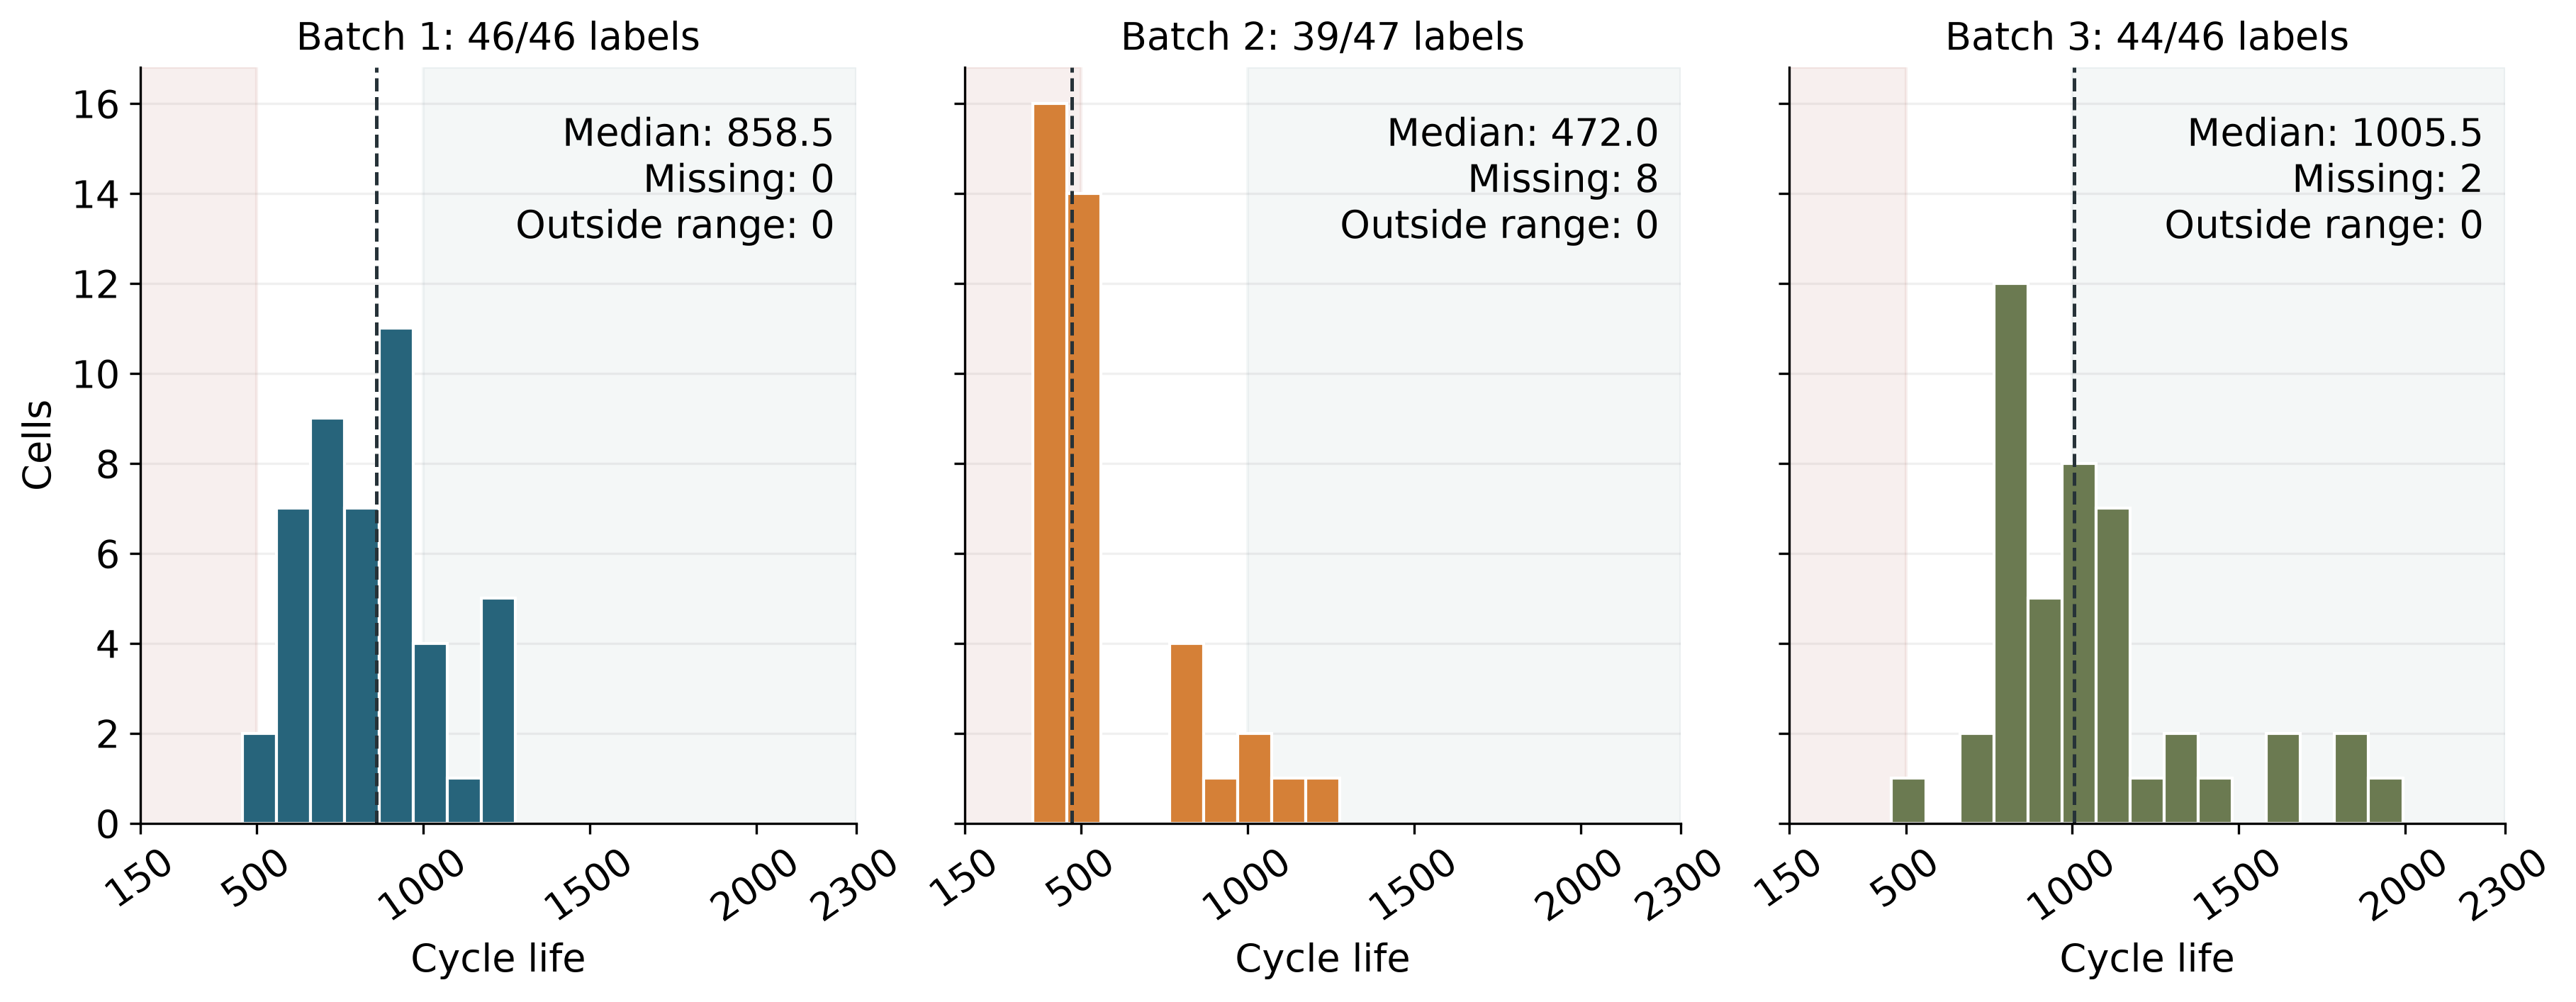

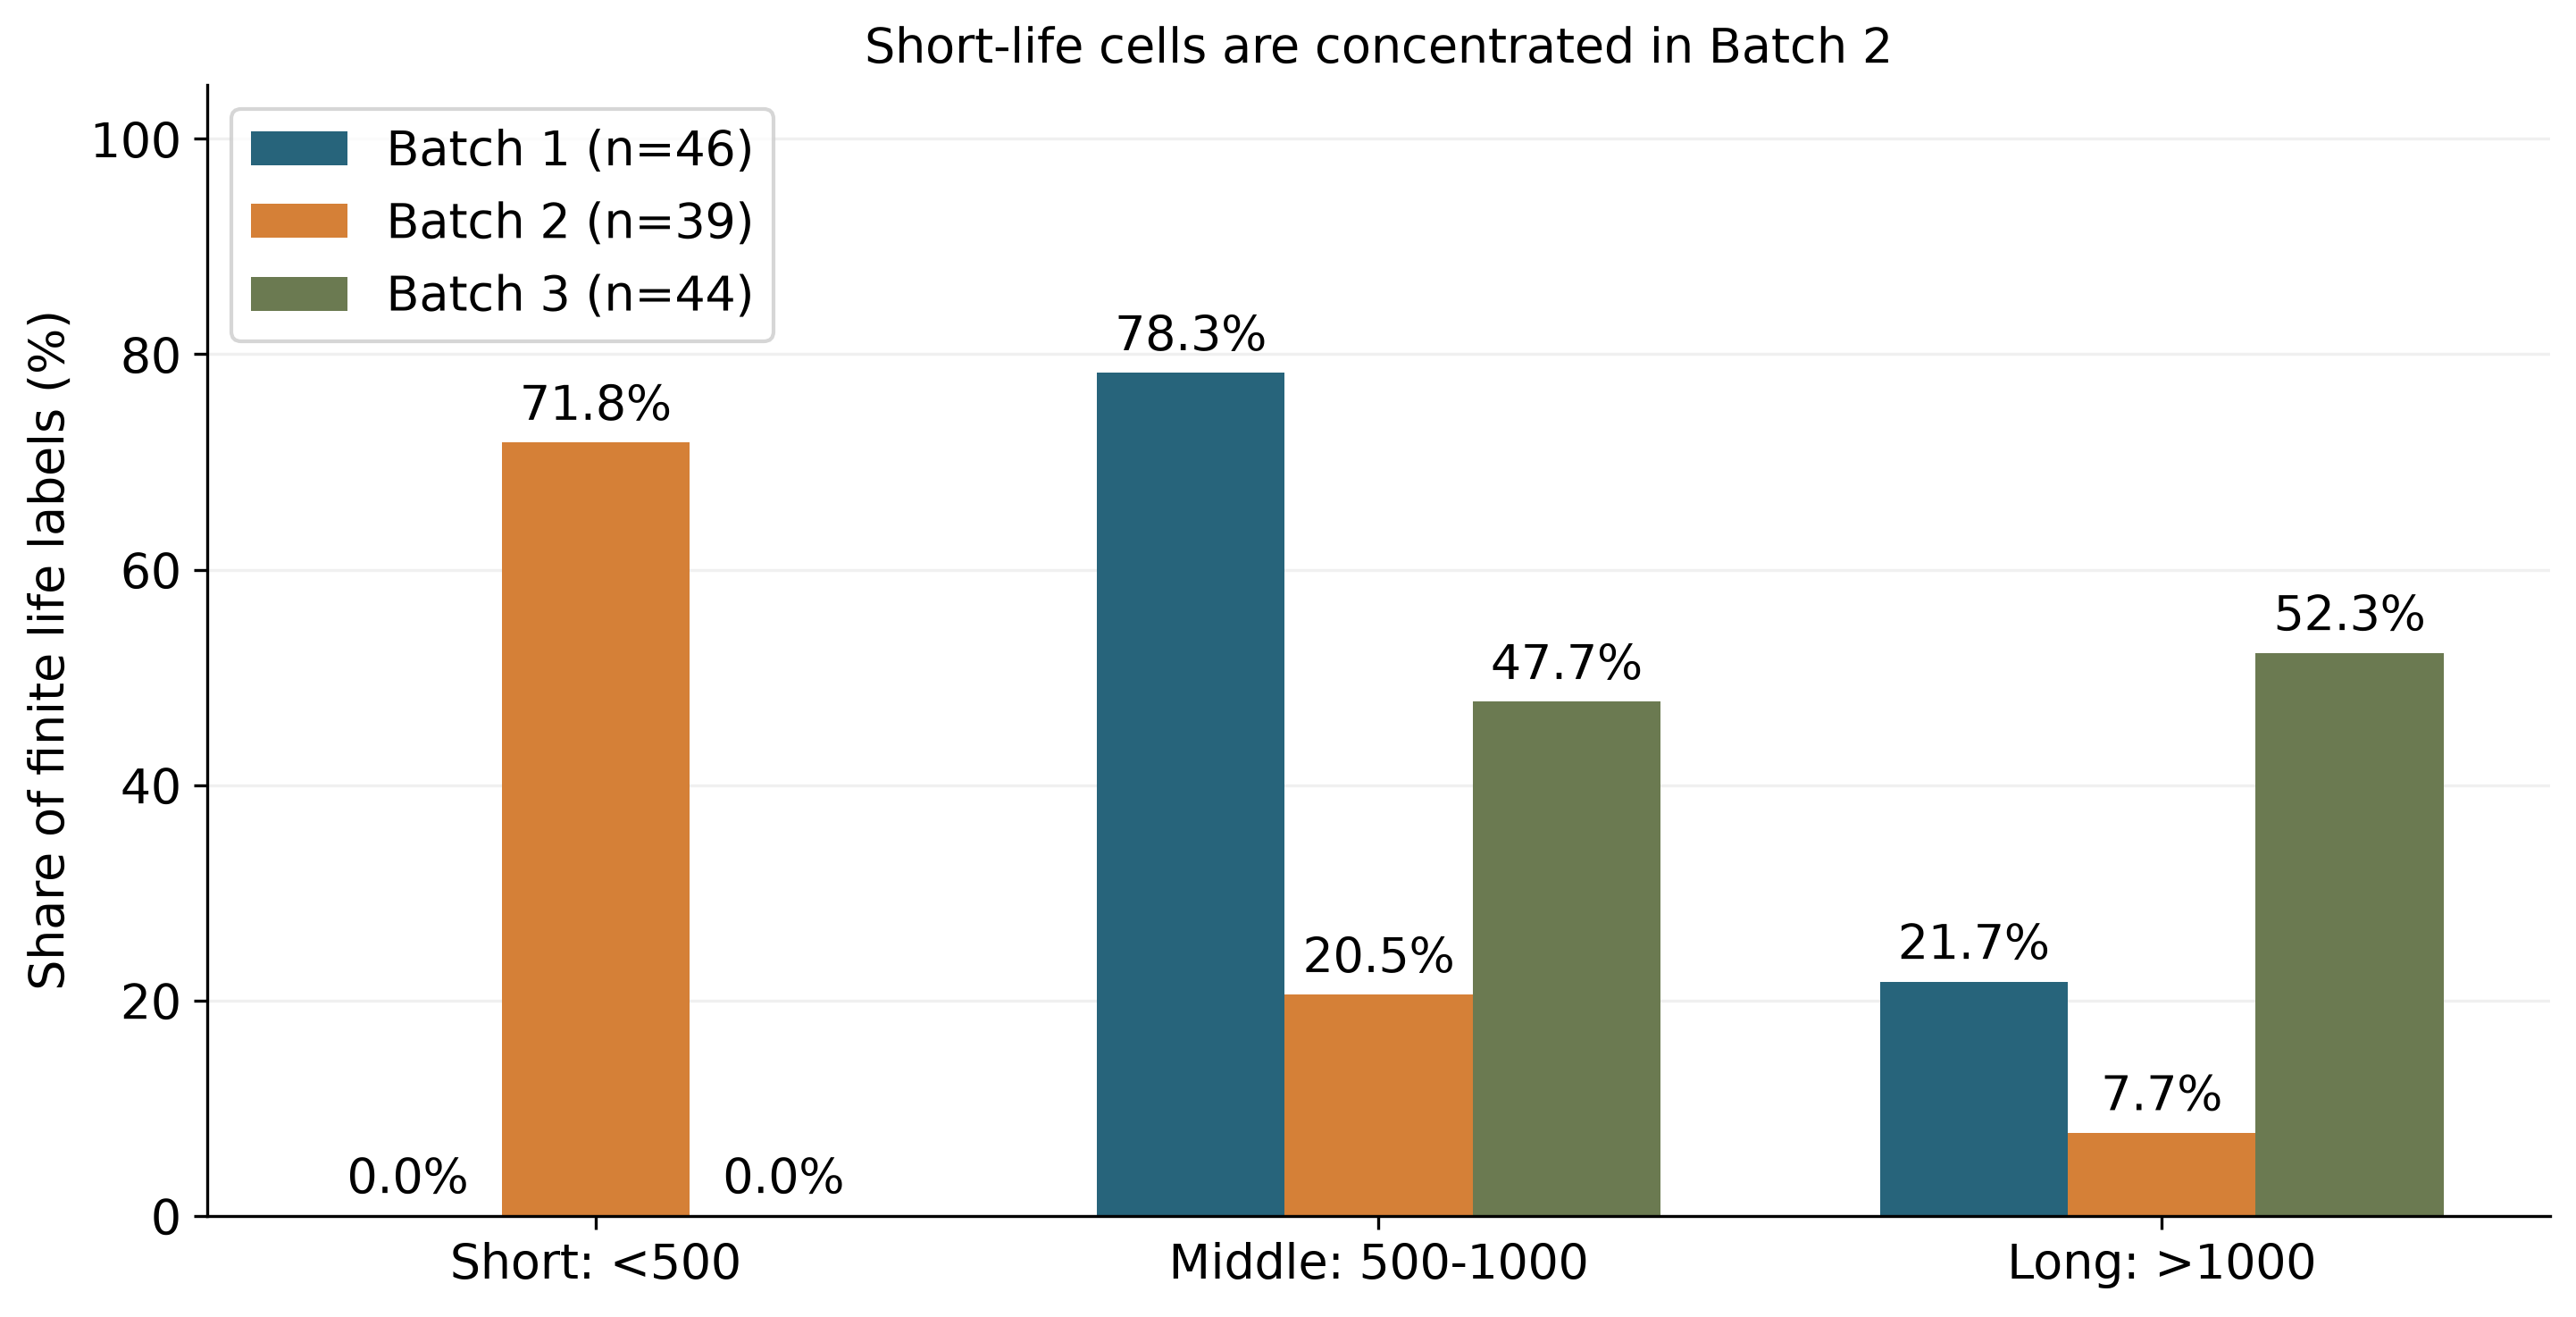

In [3]:
q1_q4 = run_distribution_protocol(PROJECT_ROOT)
display(pd.DataFrame(q1_q4['q1']).T)
show_figure('q1_life_distribution.png')
show_figure('q1_life_groups.png')

**관찰:** 중앙값은 Batch 1 858.5, Batch 2 472, Batch 3 1,005.5사이클이다.
Batch 2에는 유효 타깃 39개 중 단수명 28개(71.8%)가 있고 Batch 1·3에는 단수명 셀이 없다.
타깃 결측은 Batch 2 8개, Batch 3 2개다. 제공된 원본에서는 Batch 1·2의 분포가 유사하지 않다.

**해석:** 짧은 수명이 곧 측정 오류라는 뜻은 아니다. 프로토콜, 관측 종료, 특수 실험과 데이터 품질을 함께 확인해야 한다.
현재 자료만으로 짧은 수명의 물리적 원인을 확정할 수 없다.

**시사점:** Batch 1의 최솟값 534보다 짧은 Batch 2의 30개 셀은 학습 타깃 범위 밖의 사례다.
Batch 2 평가에서는 이 구간의 외삽 성능을 별도로 해석한다. 타깃을 임의로 복원하거나 셀을 자동 삭제하지 않는다.

In [4]:
display(pd.DataFrame(q1_q4['short_cells']).head(8))
display(pd.DataFrame(q1_q4['missing_label_cells']))

,batch_id,cell_id,cycle_life,policy_readable,C1,SOCswitch,C2
0,batch2,19,392.0,6C(60%)-3C,6.0,60.0,3.00
1,batch2,6,393.0,3.6C(9%)-5C,3.6,9.0,5.00
2,batch2,15,396.0,3.6C(9%)-5C,3.6,9.0,5.00
3,batch2,21,408.0,6C(60%)-3C,6.0,60.0,3.00
4,batch2,30,412.0,5.6C(26%)-4.5C,5.6,26.0,4.50
5,batch2,5,416.0,3.6C(30%)-6C,3.6,30.0,6.00
6,batch2,2,424.0,5.2C(50%)-4.25C,5.2,50.0,4.25
7,batch2,31,425.0,5.6C(26%)-4.5C,5.6,26.0,4.50


,batch_id,cell_id,policy_readable
0,batch2,22,VarCharge-2C-100cycles
1,batch2,23,VarCharge-4C-100cycles
2,batch2,35,VarCharge-6C-100cycles
3,batch2,36,VarCharge-8C-100cycles
4,batch2,37,3.6C(80%)-3.6C(SLOWCYCLE
5,batch2,38,4.8C(80%)-4.8C(SLOWCYCLE
6,batch2,39,3.6C(9%)-5C(SLOWCYCLE
7,batch2,40,5.2C(58%)-4C(SLOWCYCLE
8,batch3,23,4.8C(80%)-4.8C-newstructure
9,batch3,32,4.8C(80%)-4.8C-newstructure


## 2. 열화 곡선 — 초기 변화와 말기 변화는 같은가?

원본 `summary.QDischarge`를 실제 사이클 번호에 연결한다.
상세 측정이 빈 것으로 확인된 Batch 1 cycle 1은 placeholder로 표시한다.
용량 스파이크는 보존하며 전체 범위와 확대 그림을 함께 확인한다.
기울기는 10–100사이클과 마지막 관측 100사이클에서 Theil–Sen으로 탐색한다.

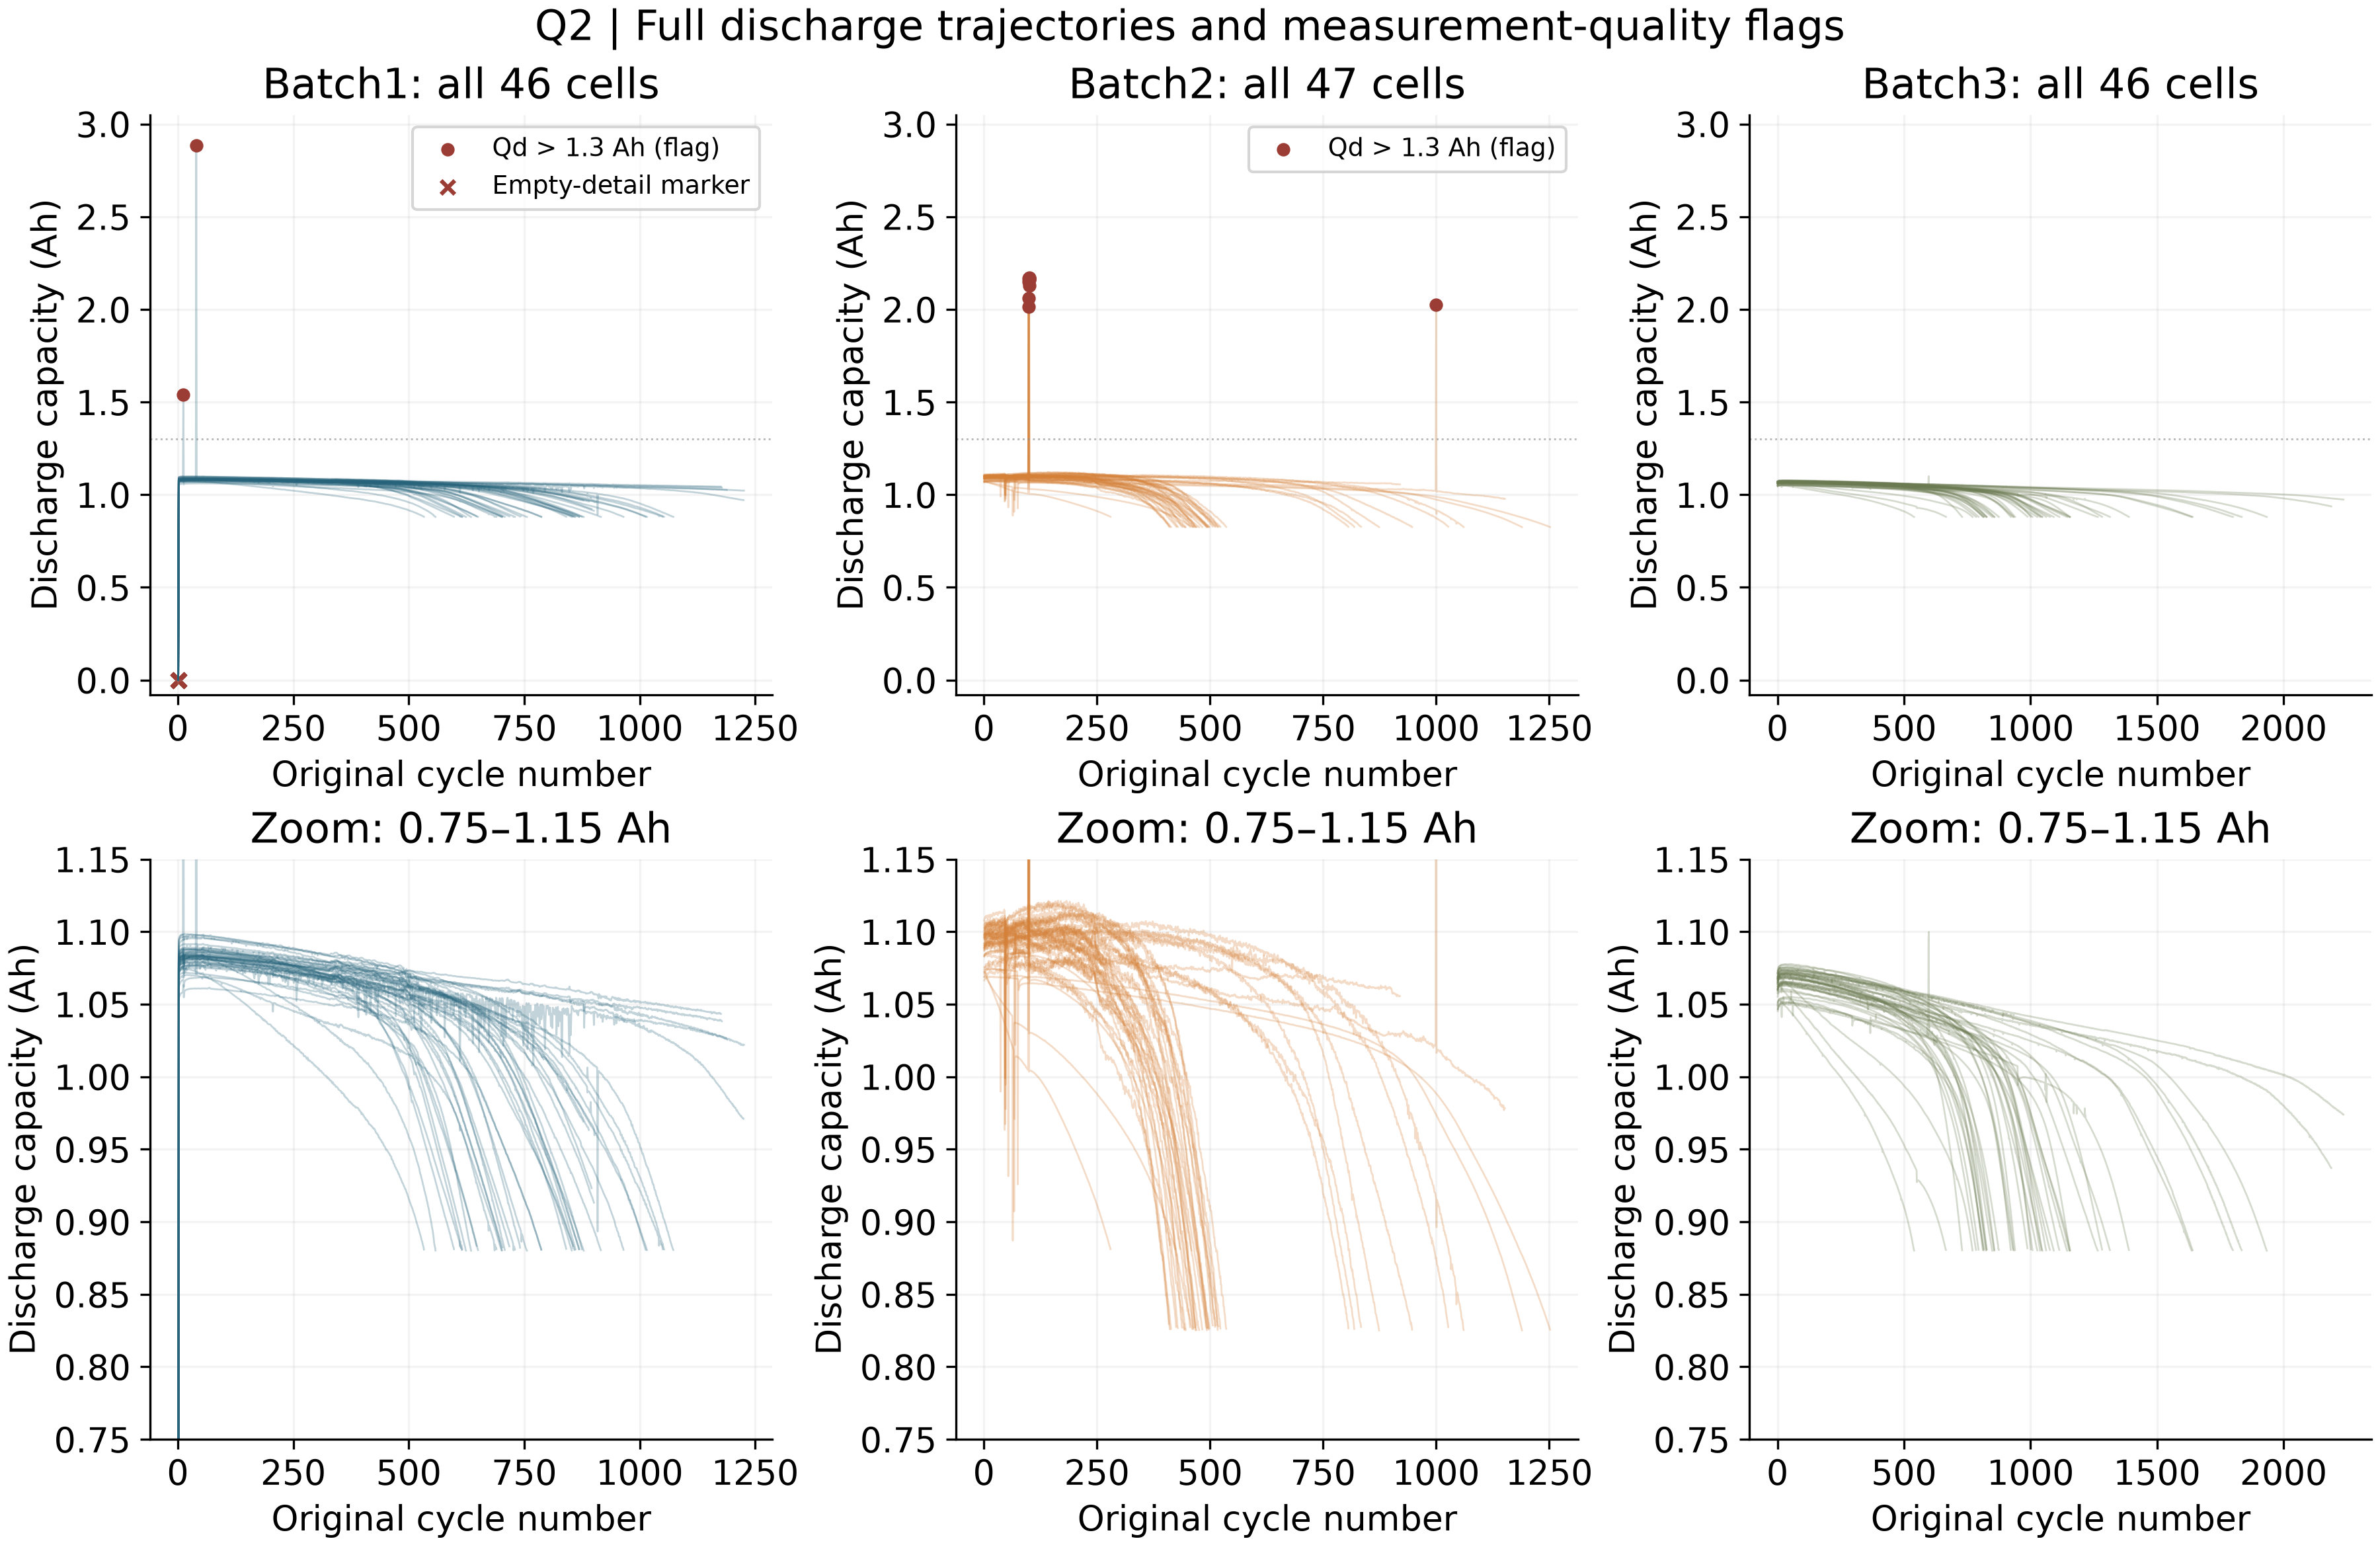

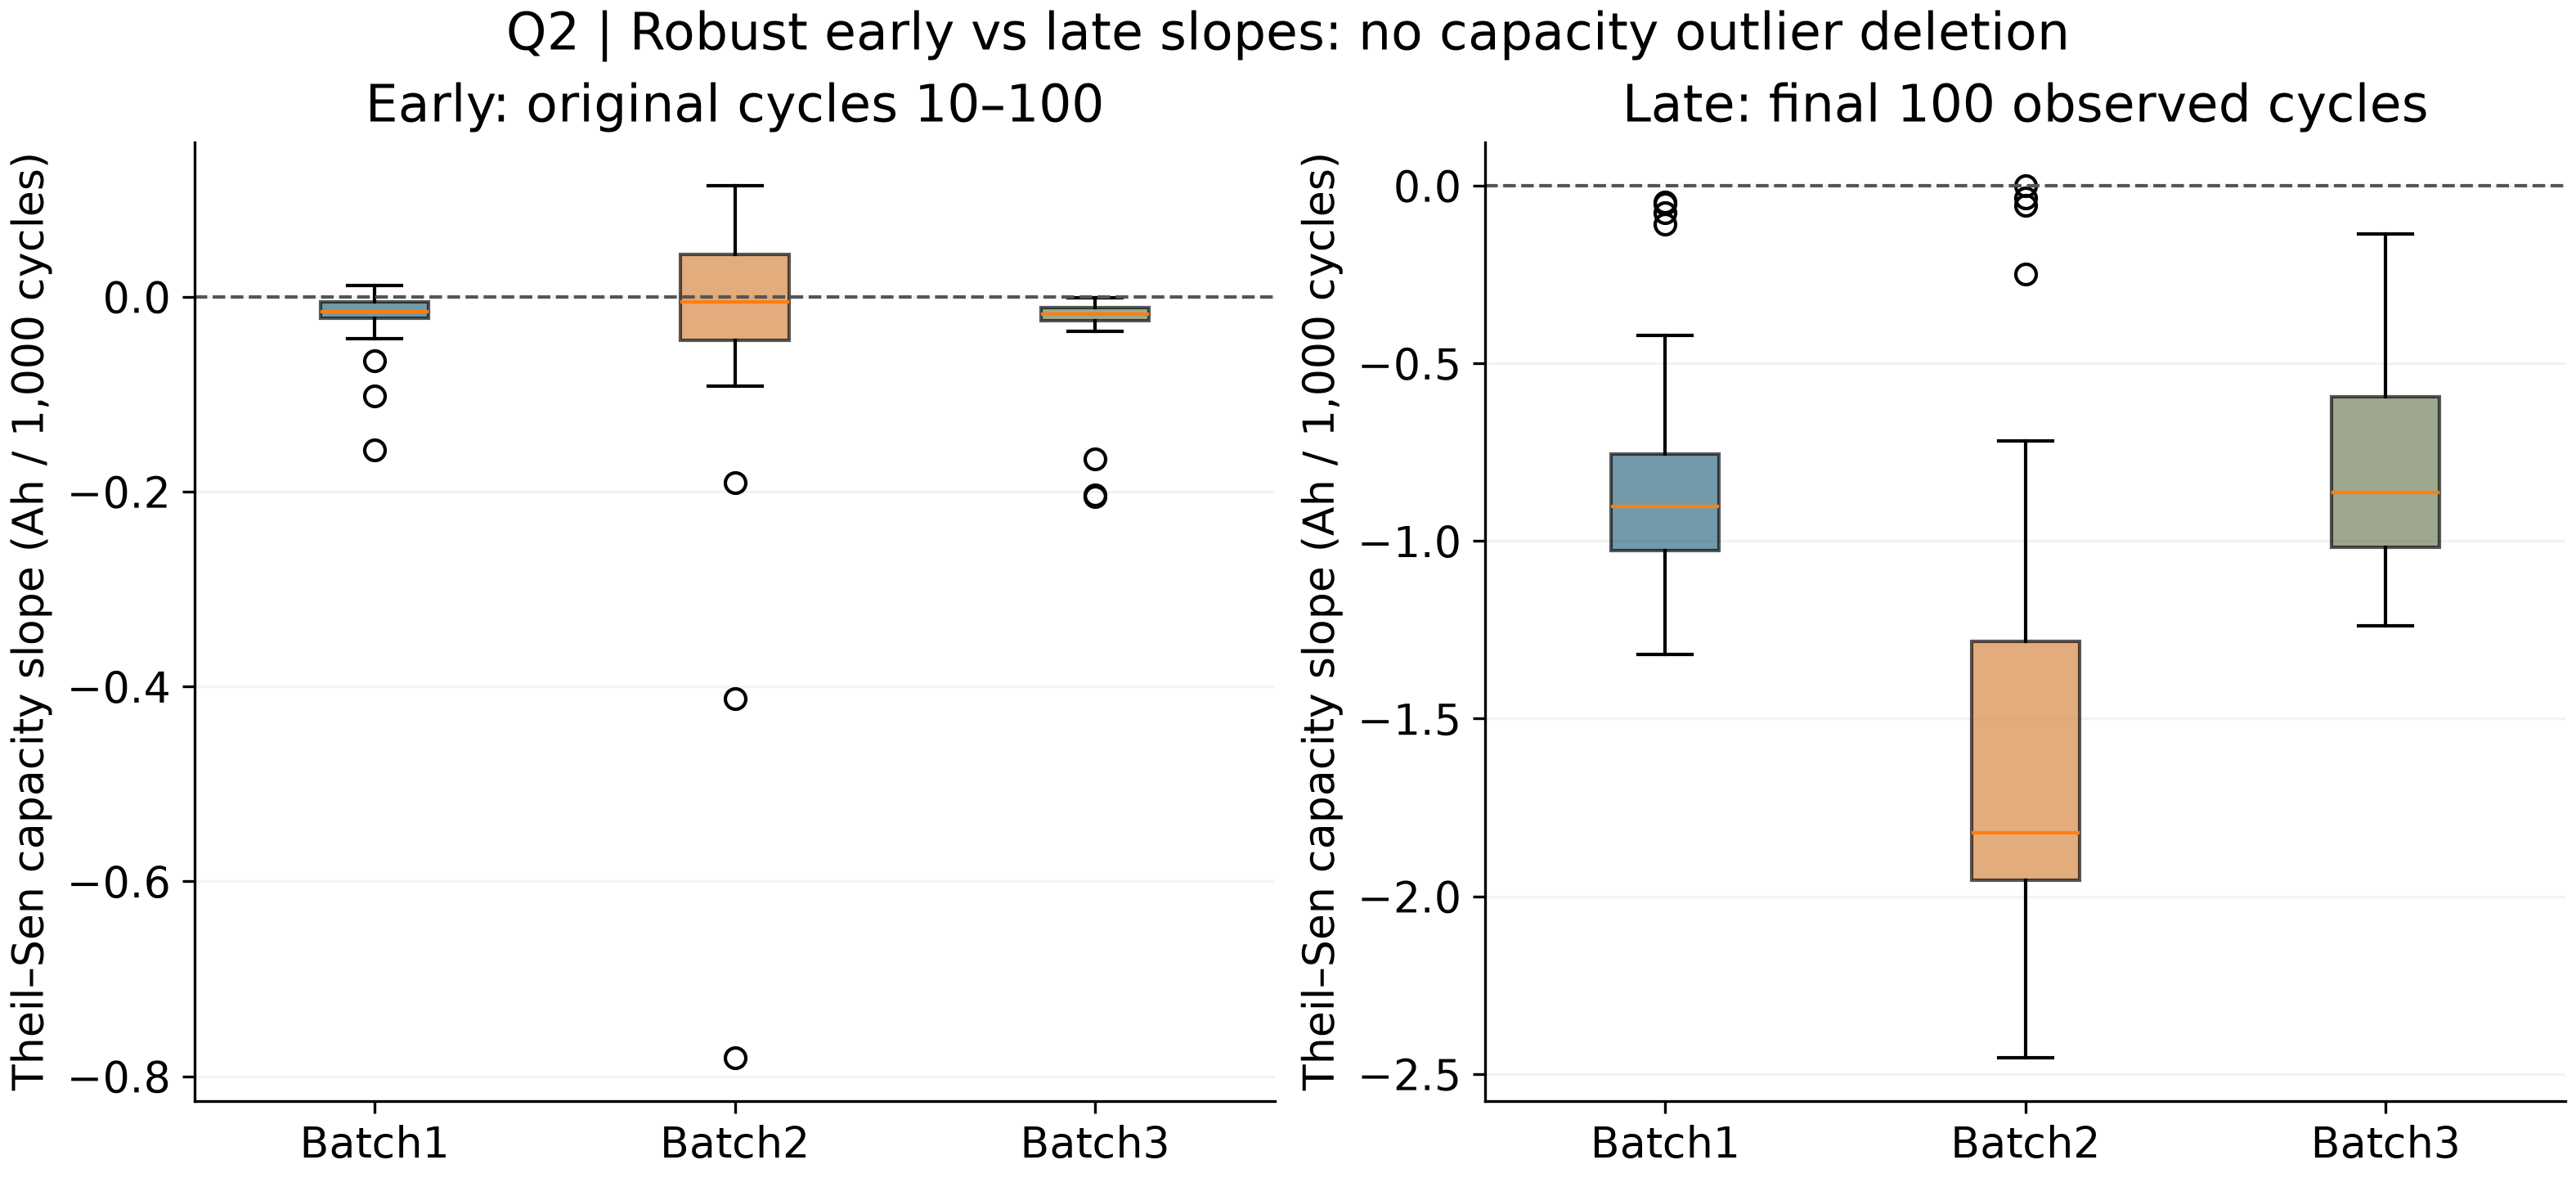

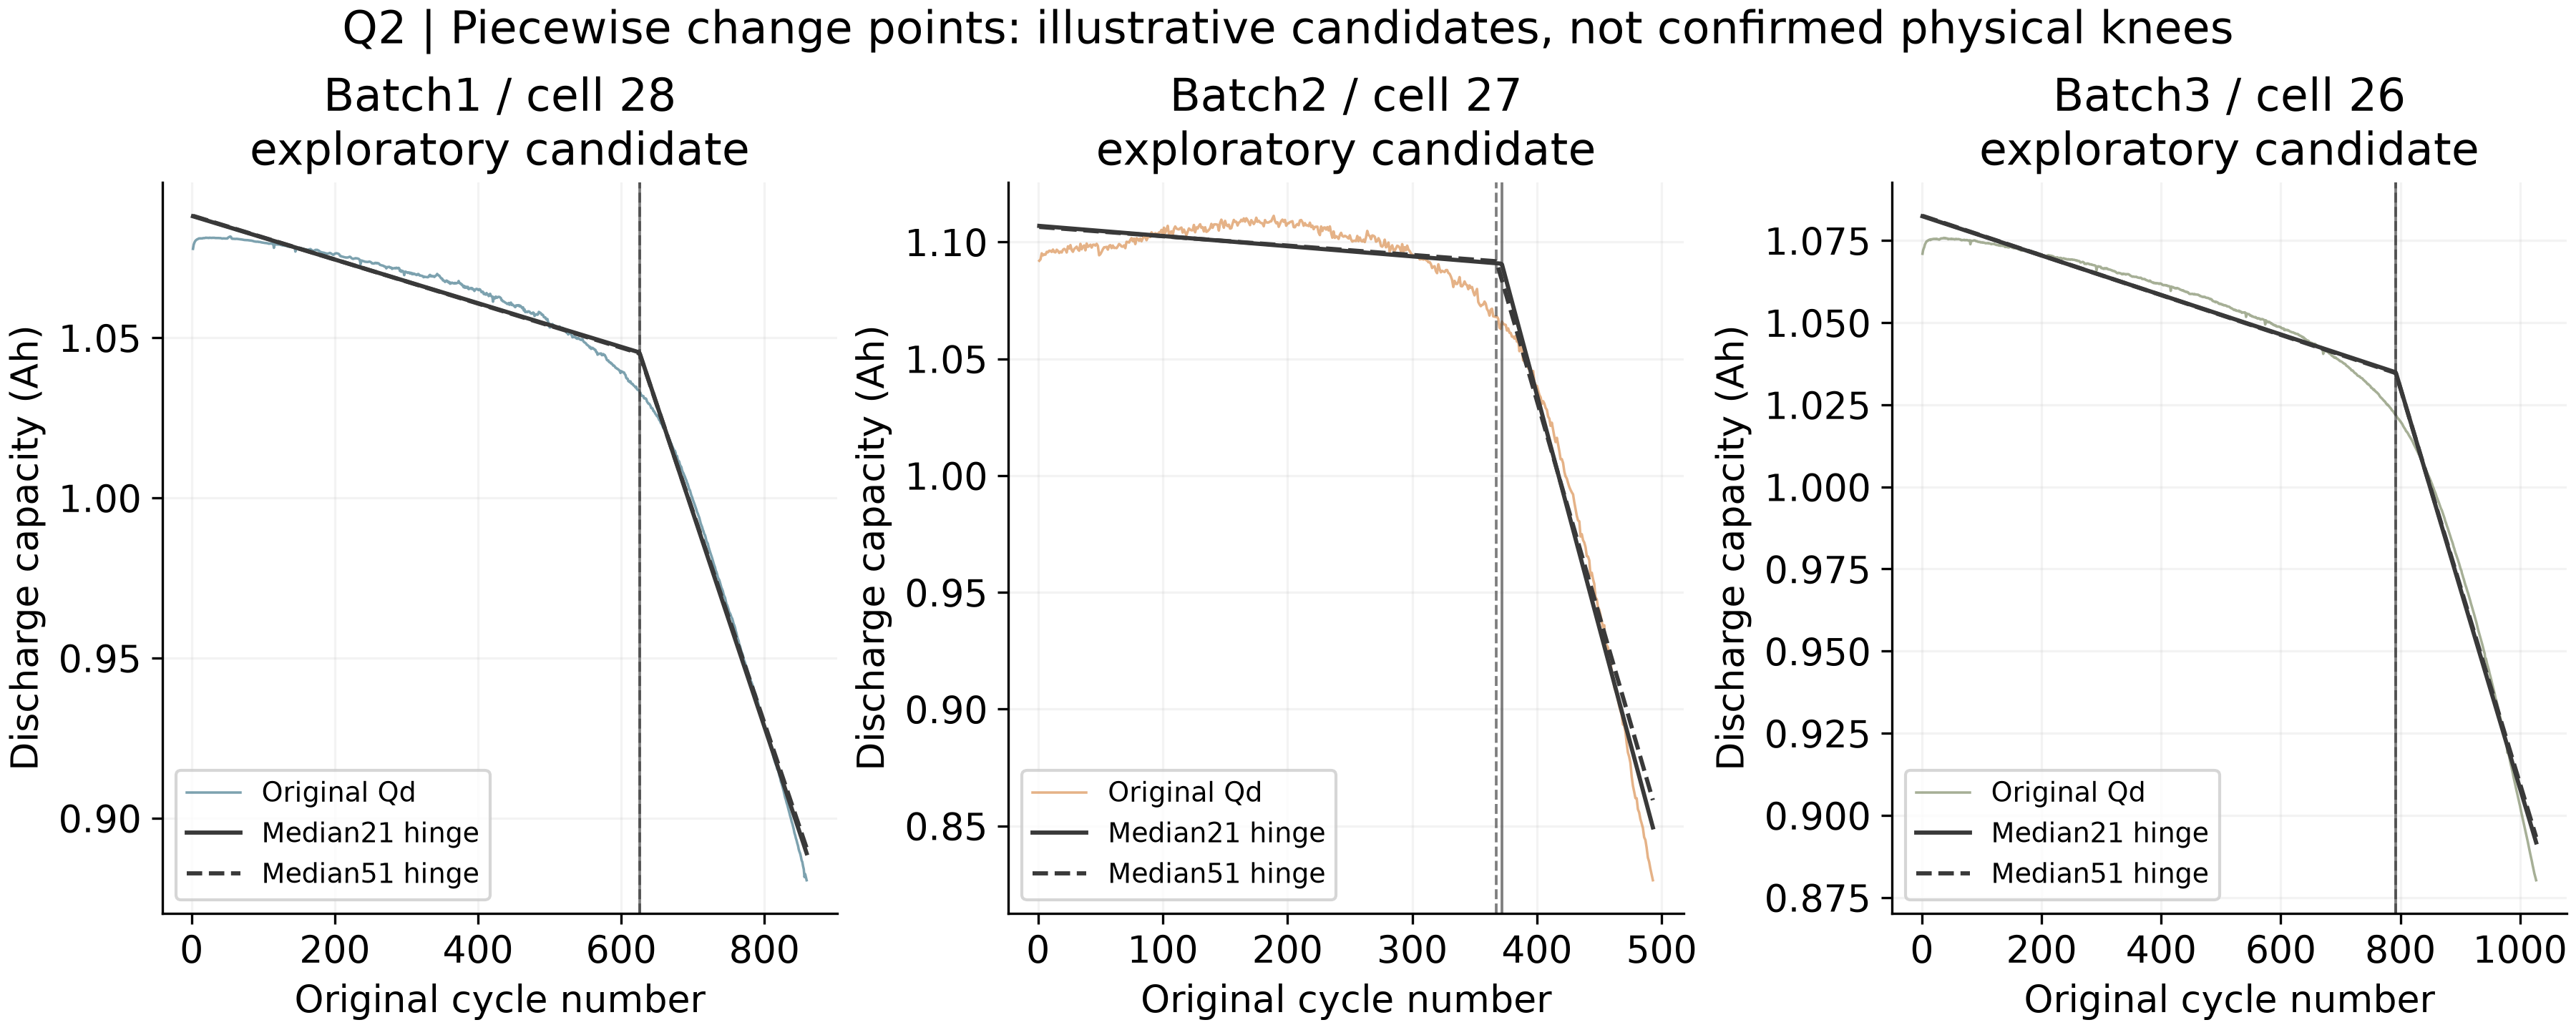

{'batch1': {'cell_count': 46,
  'summary_row_count': 38811,
  'zero_capacity_rows': 46,
  'verified_empty_marker_cell_ids': [0,
   1,
   2,
   3,
   4,
   5,
   6,
   7,
   8,
   9,
   10,
   11,
   12,
   13,
   14,
   15,
   16,
   17,
   18,
   19,
   20,
   21,
   22,
   23,
   24,
   25,
   26,
   27,
   28,
   29,
   30,
   31,
   32,
   33,
   34,
   35,
   36,
   37,
   38,
   39,
   40,
   41,
   42,
   43,
   44,
   45],
  'QD_range_Ah': [0.0, 2.8840845],
  'early_slope_Ah_per_1000_cycles': {'count': 46,
   'min': -0.15732962962962857,
   'q25': -0.02250141700404721,
   'median': -0.015706250000000616,
   'q75': -0.005762348217785379,
   'max': 0.01179333333333569},
  'late_slope_Ah_per_1000_cycles': {'count': 46,
   'min': -1.320148731626363,
   'q25': -1.027516422191553,
   'median': -0.9038380990409971,
   'q75': -0.7545139206685578,
   'max': -0.04737763691683594},
  'late_more_negative_count': 46,
  'late_more_negative_pct': 100.0,
  'exploratory_knee_candidate_count': 4

In [5]:
q2 = run_degradation(PROJECT_ROOT)
show_figure('q2_degradation_curves.png')
show_figure('q2_early_late_slopes.png')
show_figure('q2_knee_examples.png')
display(q2['batches'])

**해석:** 초기 용량의 상승·작은 변화와 말기 감소가 함께 관찰될 수 있다.
초기 기울기를 항상 '열화 속도'로 부르면 활성화·측정 변동을 열화와 혼동할 수 있다.

Knee는 21·51점 이동 중앙값으로 만든 곡선에 연속 두 직선 모형을 적용한 **탐색 후보**다.
두 평활화의 변화점 위치와 기울기 방향, 한 직선 대비 SSE 개선을 비교한다.
평활화·임계값 의존성과 관측 종료의 영향을 가지므로 물리적 Knee를 확정했다고 쓰지 않는다.

**시사점:** 전체 곡선·말기 기울기·Knee는 수명 이해를 위한 EDA 결과다.
100사이클 시점의 예측 입력으로 사용하면 미래 정보가 포함되므로 모델 피처에서 배제한다.

## 3. ΔQ(V) — 초기 곡선 차이가 수명 그룹과 연관되는가?

`ΔQ(V) = Qdlin(cycle 100,V) - Qdlin(cycle 10,V)`.
셀 안의 전압 격자가 정확히 같은지 확인한 뒤 직접 뺀다. 보간·가상 시점 이동을 하지 않는다.
분산은 원본 1,000개 전압 지점에서 `ddof=0`으로 계산한다.
주 검정 신호는 Ah²로 계산한 분산의 `log10` 값이다. 0 분산에 임의의 epsilon을 더하지 않는다.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


Cells retained: 139
Groups: {('batch1', 'long'): 10, ('batch1', 'middle'): 36, ('batch2', 'long'): 3, ('batch2', 'middle'): 8, ('batch2', 'short'): 28, ('batch2', 'unknown'): 8, ('batch3', 'long'): 23, ('batch3', 'middle'): 21, ('batch3', 'unknown'): 2}
Global exact grid match: True
batch1 [{'feature': 'delta_q_var', 'n': 46, 'pearson': -0.8378261389128988, 'spearman': -0.8711607269559923}, {'feature': 'delta_q_log10var', 'n': 46, 'pearson': -0.8861231036774865, 'spearman': -0.8711607269559923}, {'feature': 'delta_q_min', 'n': 46, 'pearson': 0.8816450170696561, 'spearman': 0.8500061691261938}, {'feature': 'delta_q_range', 'n': 46, 'pearson': -0.8818662964221301, 'spearman': -0.8495127683604842}, {'feature': 'delta_q_mean', 'n': 46, 'pearson': 0.853809784463006, 'spearman': 0.8281115101478308}]
batch2 [{'feature': 'delta_q_var', 'n': 39, 'pearson': -0.7327873034697585, 'spearman': -0.7089786451951733}, {'feature': 'delta_q_log10var', 'n': 39, 'pearson': -0.9018830736836403, 'spearman': 

{'all_139_cells_exactly_equal': True,
 'point_count': 1000,
 'voltage_first': 3.5,
 'voltage_last': 2.0,
 'voltage_min': 2.0,
 'voltage_max': 3.5,
 'interpolation_performed': False,
 'scope': 'Actual cycles 10 and 100 only; equality here does not establish alignment at every later cycle or equality of Qdlin capacity-origin/collection definitions across batches.'}

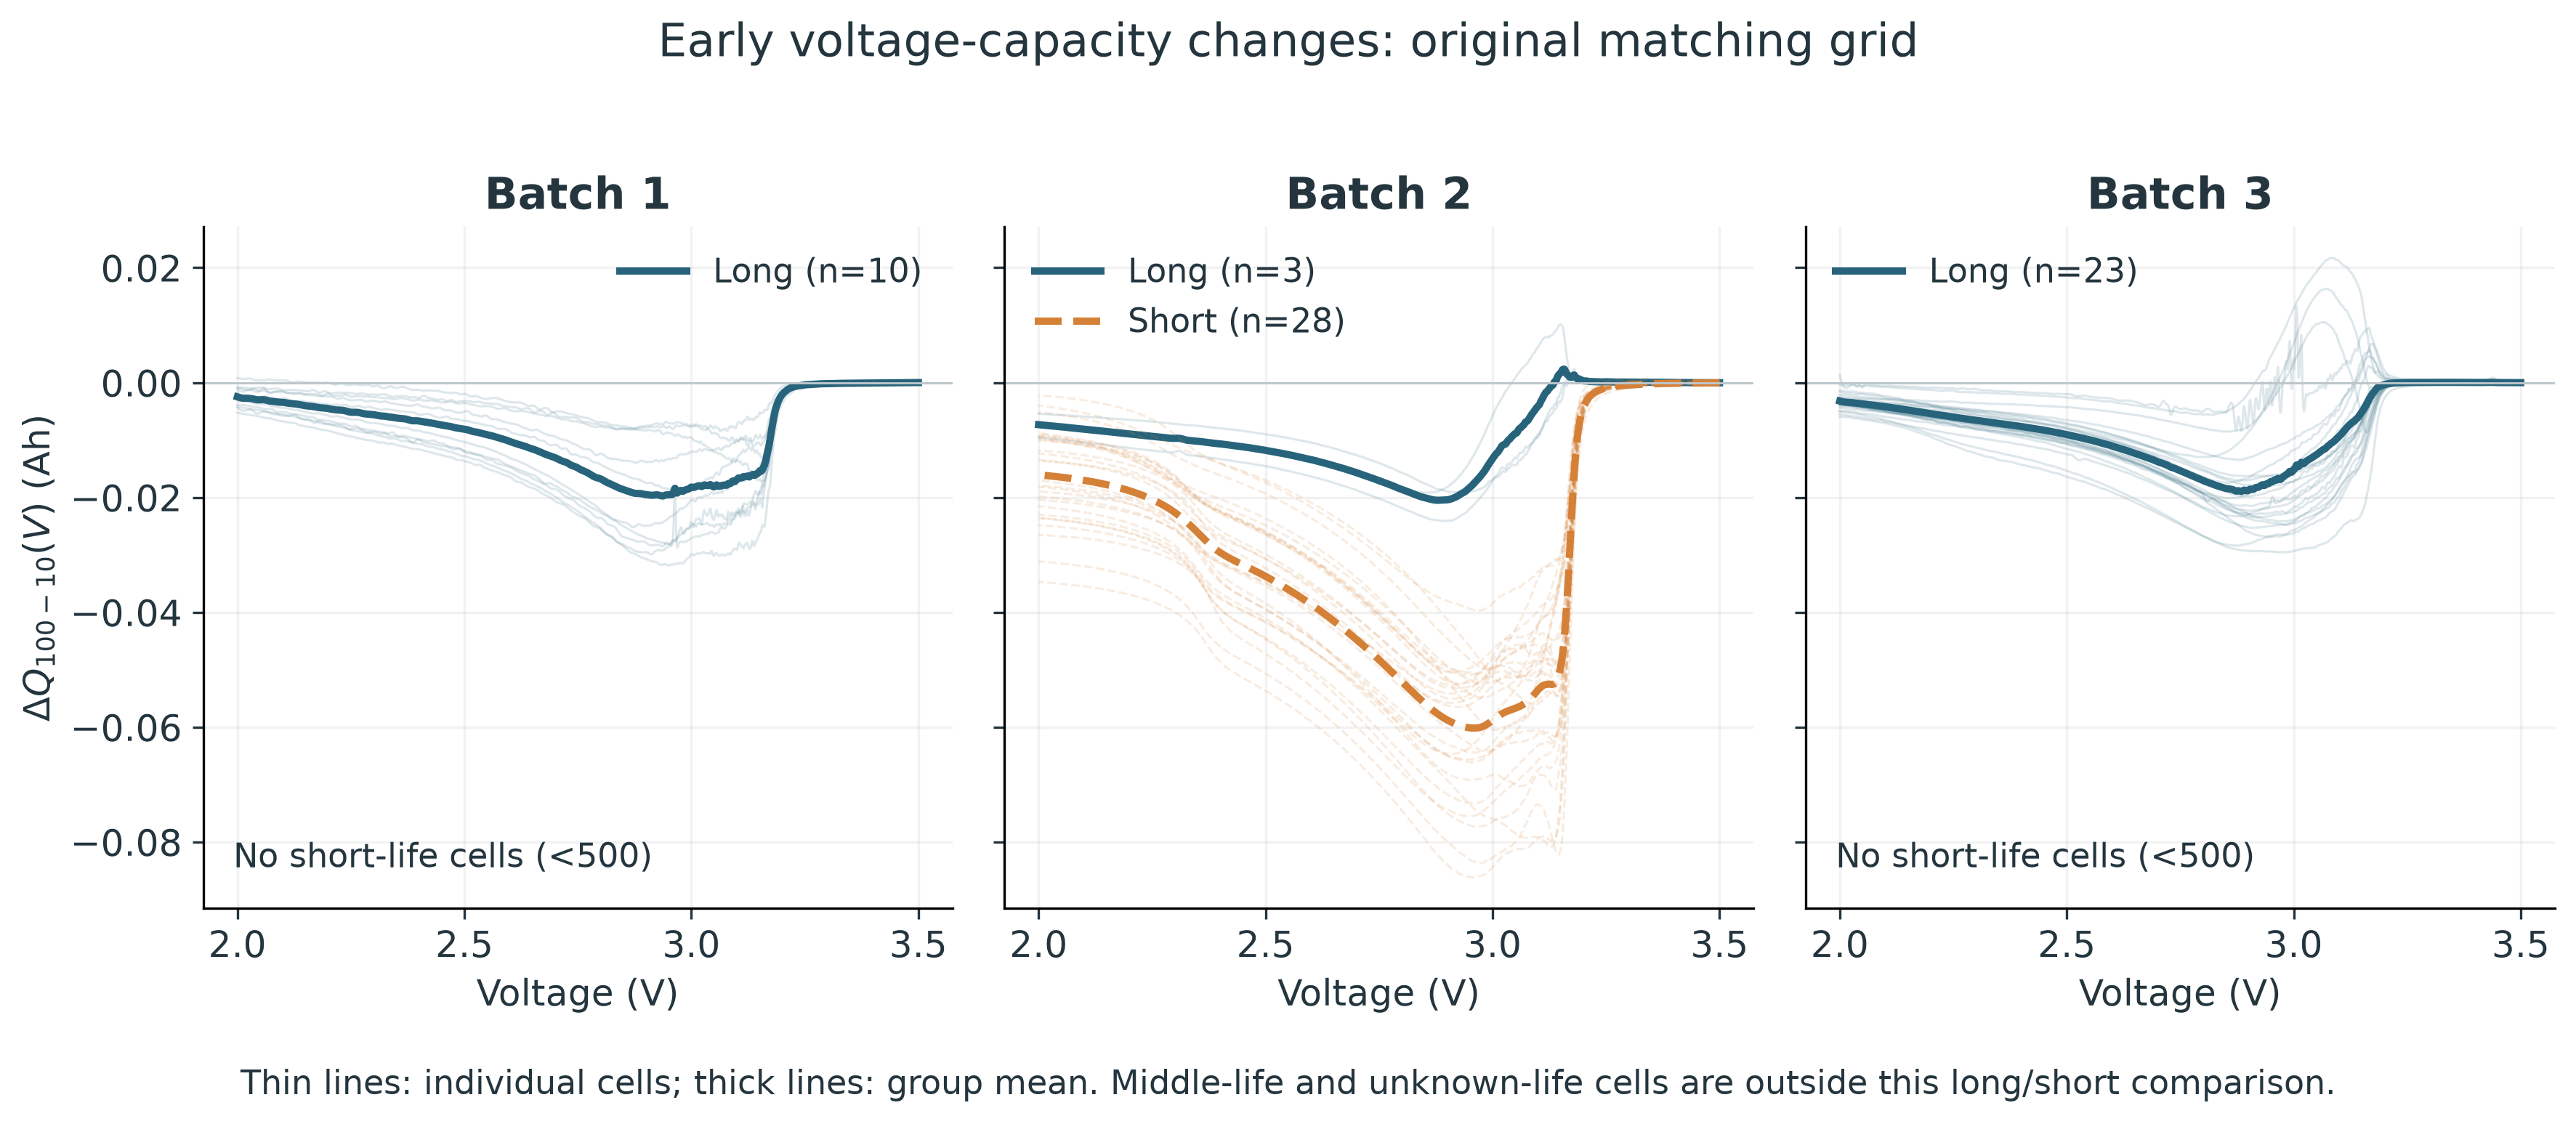

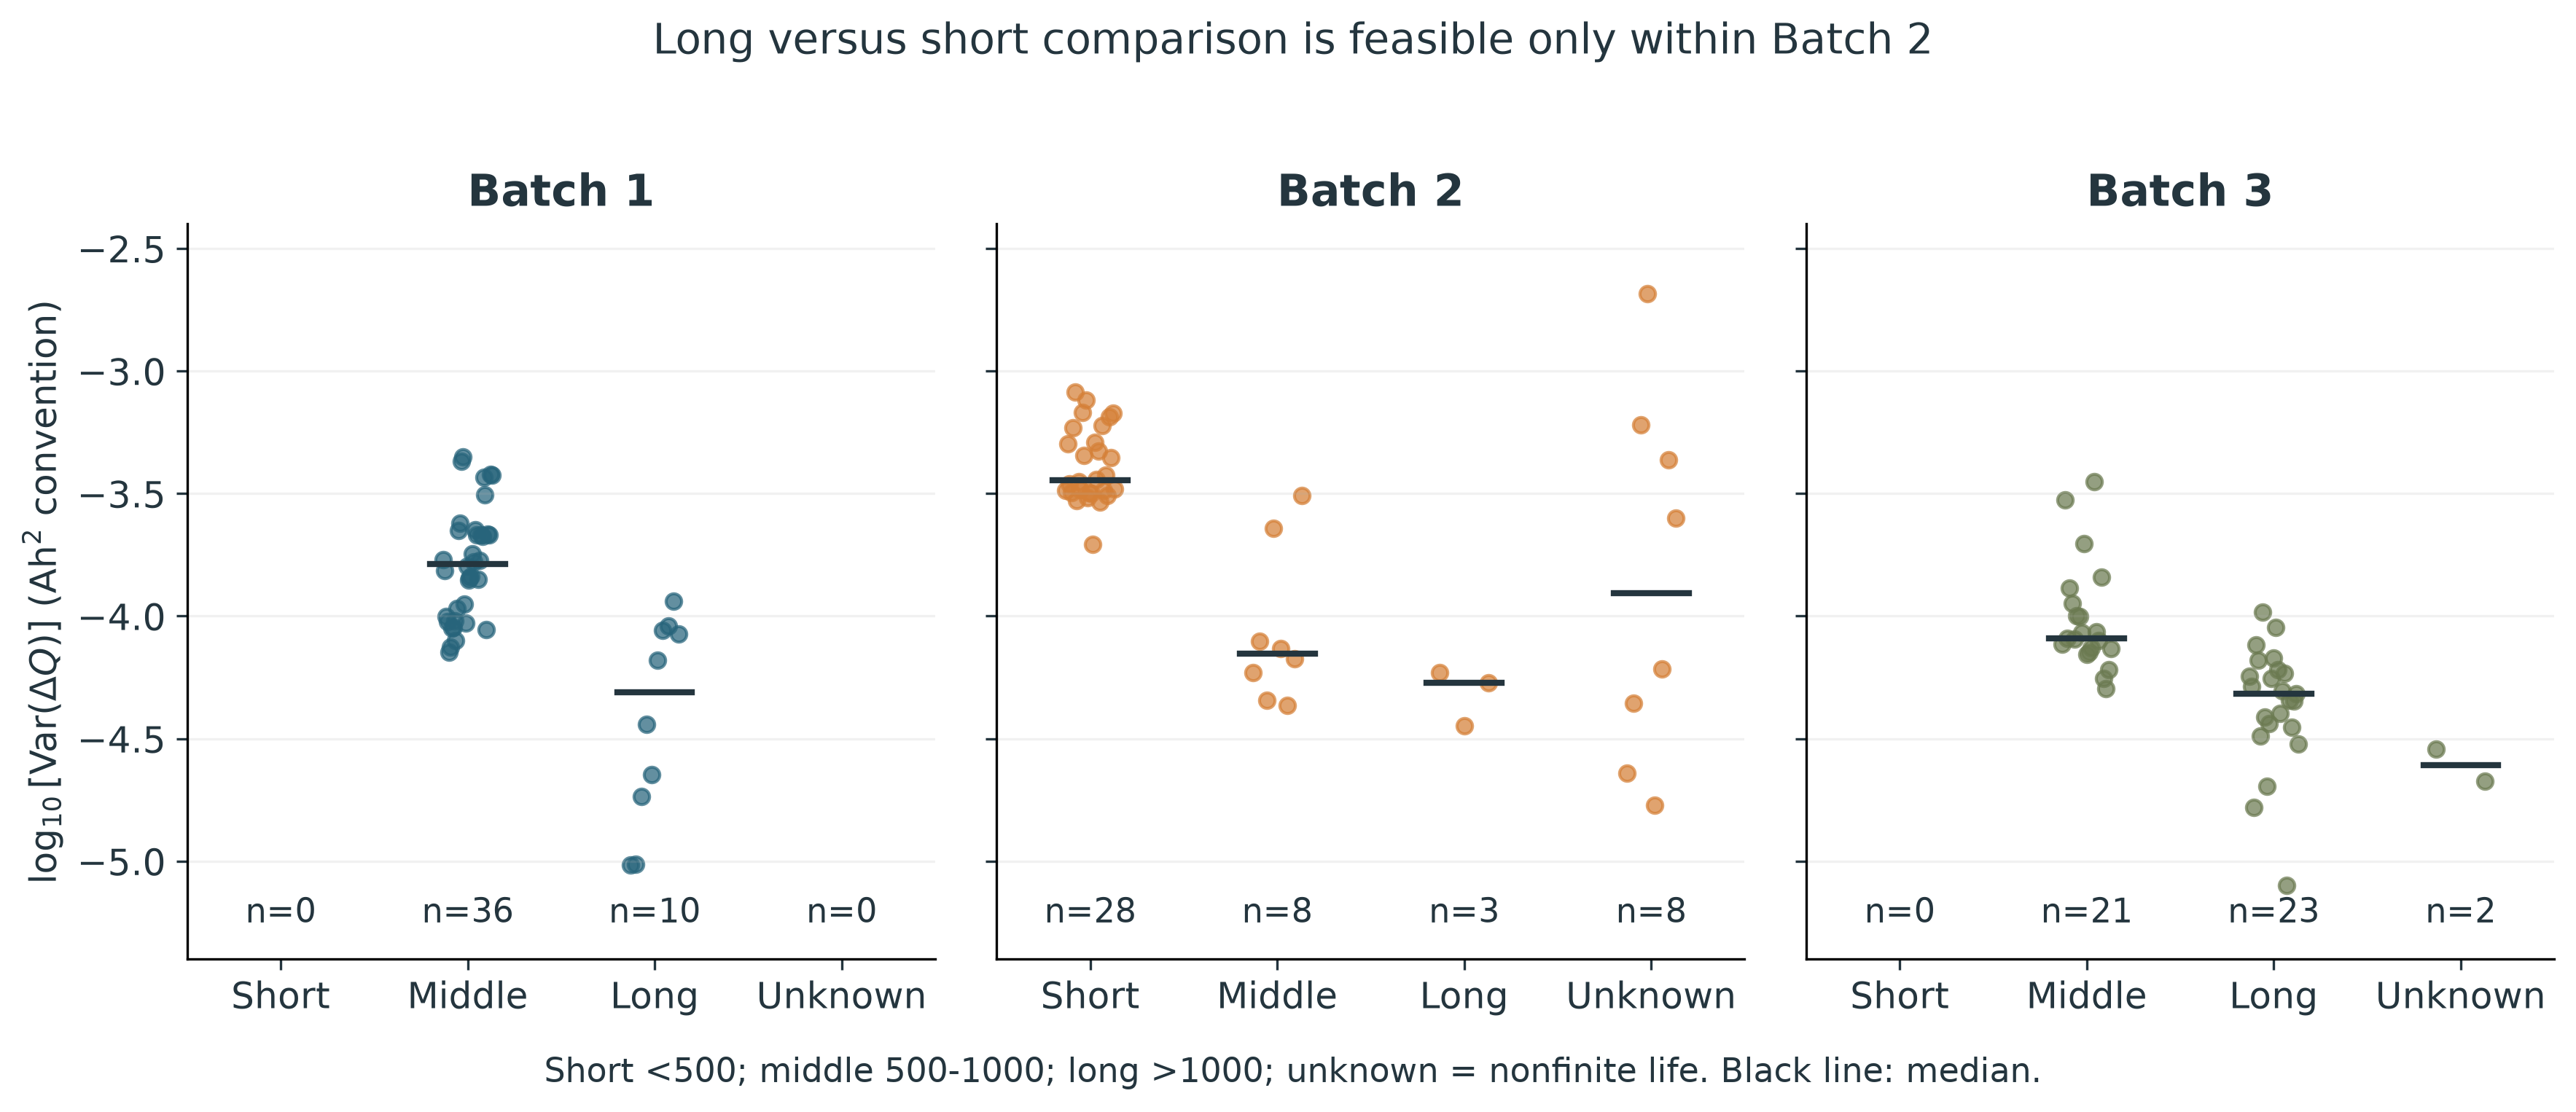

In [6]:
q3_q5 = run_early_signals(PROJECT_ROOT)
display(q3_q5['q3']['grid_checks'])
show_figure('q3_delta_q_curves.png')
show_figure('q3_logvariance_groups.png')

### 가설검정: Batch 2 장수명 3셀 vs 단수명 28셀

다른 배치에는 단수명 셀이 없어 Batch 2 안에서 비교한다. 500–1,000사이클의 중간 그룹과
타깃 결측 셀은 이 두 그룹 검정의 대상이 아니며 원본에서는 유지한다.

- 주 검정: 양측 Welch t-test, 유의수준 0.05.
- H0: 두 그룹의 모집단 `log10(ΔQ 분산)` 평균이 같다.
- H1: 두 평균이 다르다. 검정 통계와 효과 방향은 장수명 - 단수명이다.
- 보완: 평균 차이를 통계량으로 하는 정확 순열검정. 31개 중 3개를 고르는 4,495개 분할을 모두 계산한다.
- 순열검정의 H0는 교환 가능한 그룹 표시 아래 같은 분포에서 나온다는 가정이다. 평균 동일만 가정하는 Welch와 구분한다.

독립 표본은 셀이다. 장수명 n=3으로 정규성을 충분히 점검할 수 없고, 프로토콜 교란이 남아 있다.
EDA 후 선택한 비교이므로 결과는 탐색적 근거이며 인과관계·독립 확증·모델 성능의 증명이 아니다.

{'status': 'executed',
 'primary_feature': 'delta_q_log10var',
 'scope': 'batch2 only',
 'cell_unit': 'One original cell per observation; 1000 voltage coordinates are not independent samples.',
 'alpha': 0.05,
 'alternative': 'two-sided',
 'welch_null': 'Equal population means of log10(Var(delta Q)); unequal variances allowed.',
 'n_long': 3,
 'n_short': 28,
 'long_cell_ids': [33, 34, 43],
 'mean_long': -4.317331807095357,
 'mean_short': -3.3858322785630257,
 'difference_long_minus_short': -0.9314995285323313,
 'geometric_mean_variance_ratio_long_over_short': 0.11708478733854763,
 'variance_ratio_note': 'Back-transform of the difference in mean log10 variance; ratio of geometric means, not ratio of arithmetic means.',
 'welch_t': -12.814500221783948,
 'welch_df': 2.823528945473982,
 'welch_p_two_sided': 0.0013781533512780266,
 'welch_95pct_ci_difference': [-1.1712334263815927, -0.69176563068307],
 'welch_reject_at_0_05': True,
 'permutation_null': 'Same underlying distributions with ex

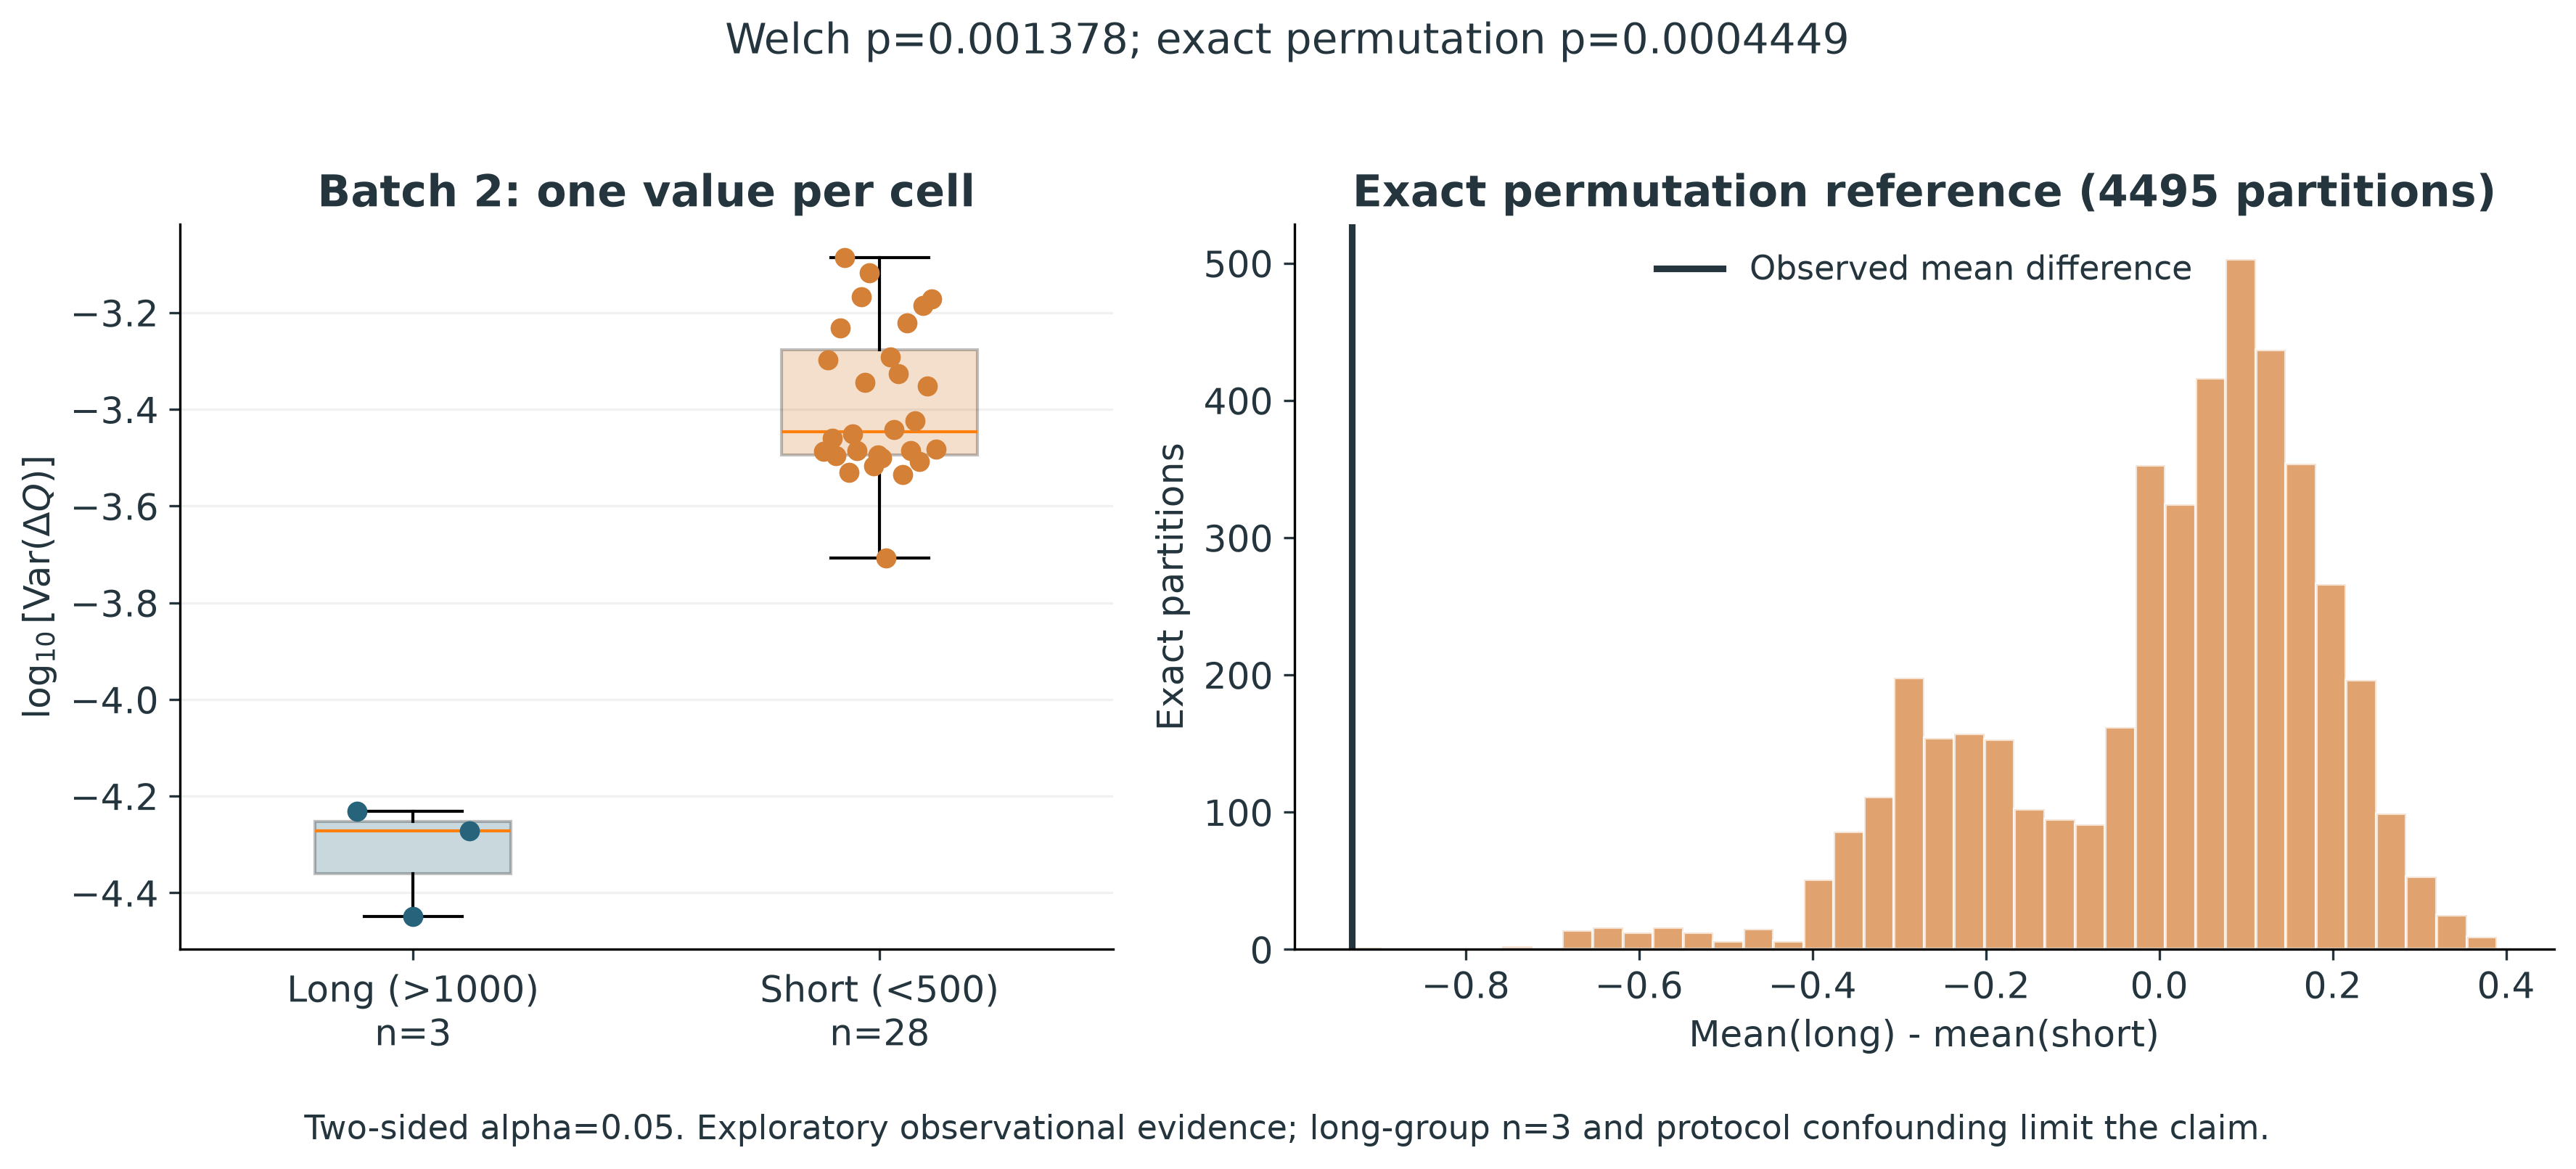

In [7]:
test = q3_q5['q3']['hypothesis_test']
display({key:value for key,value in test.items()
         if key not in ('permutation_null_distribution','short_cell_ids','protocols_by_group')})
show_figure('q3_test_result.png')

**결과:** 평균 차이는 -0.9315, Welch t=-12.8145, df=2.8235, p=0.001378이다.
평균 차이의 95% 신뢰구간은 [-1.1712, -0.6918]이고 정확 순열검정 p=0.0004449다.
두 방법 모두 5% 기준에서 귀무가설을 기각한다.

**해석:** 장수명 그룹의 ΔQ 분산 기하평균은 단수명 그룹의 약 0.117배다.
변화 곡선의 퍼짐이 작을수록 긴 수명과 연관되는 근거가 있다.
다만 장수명 3셀·관찰 자료·EDA 후 검정의 한계가 있어 다른 배치에도 같은 효과를 확정할 수 없다.

**시사점:** ΔQ 분산은 우선 검증할 피처 후보다. 가설검정은 예측 성능 평가를 대신하지 않는다.

## 4. 충전 조건 — 고속 충전은 항상 짧은 수명과 연결되는가?

`policy_readable` 원문별 수명 평균과 표본 수를 비교한다.
표준 두 단계 프로토콜에서 C1·전환 SOC·C2를 분리하되 suffix를 보존하고, 지원하지 않는
VarCharge 형식은 별도 상태로 남긴다.
전류 패턴은 실제 cycle 10의 원본 I 값 중 I>0인 표본으로 비교한다.
표본 평균은 시간 가중 평균이나 정책 전체의 평균 C-rate를 뜻하지 않는다.

,batch_id,policy_parse_status,count
0,batch1,parsed_standard,46
1,batch2,parsed_standard,30
2,batch2,parsed_with_suffix,13
3,batch2,unsupported_format,4
4,batch3,parsed_with_suffix,46


,batch_id,policy_readable,n_cells,n_valid_life,n_missing_life,mean_life,median_life,std_life,min_life,max_life
0,batch1,3.6C(80%)-3.6C,3,3,0,1182.000000,1179.0,7.000000,1177.0,1190.0
1,batch1,4C(80%)-4C,2,2,0,1226.500000,1226.5,0.707107,1226.0,1227.0
2,batch1,4.4C(80%)-4.4C,1,1,0,1074.000000,1074.0,NaN,1074.0,1074.0
3,batch1,4.8C(80%)-4.8C,2,2,0,753.000000,753.0,165.462987,636.0,870.0
4,batch1,5.4C(40%)-3.6C,2,2,0,966.500000,966.5,123.743687,879.0,1054.0
5,batch1,5.4C(50%)-3C,2,2,0,847.000000,847.0,83.438600,788.0,906.0
6,batch1,5.4C(50%)-3.6C,2,2,0,899.500000,899.5,3.535534,897.0,902.0
7,batch1,5.4C(60%)-3C,2,2,0,799.500000,799.5,113.844192,719.0,880.0
8,batch1,5.4C(60%)-3.6C,2,2,0,859.500000,859.5,3.535534,857.0,862.0
9,batch1,5.4C(70%)-3C,2,2,0,739.500000,739.5,68.589358,691.0,788.0


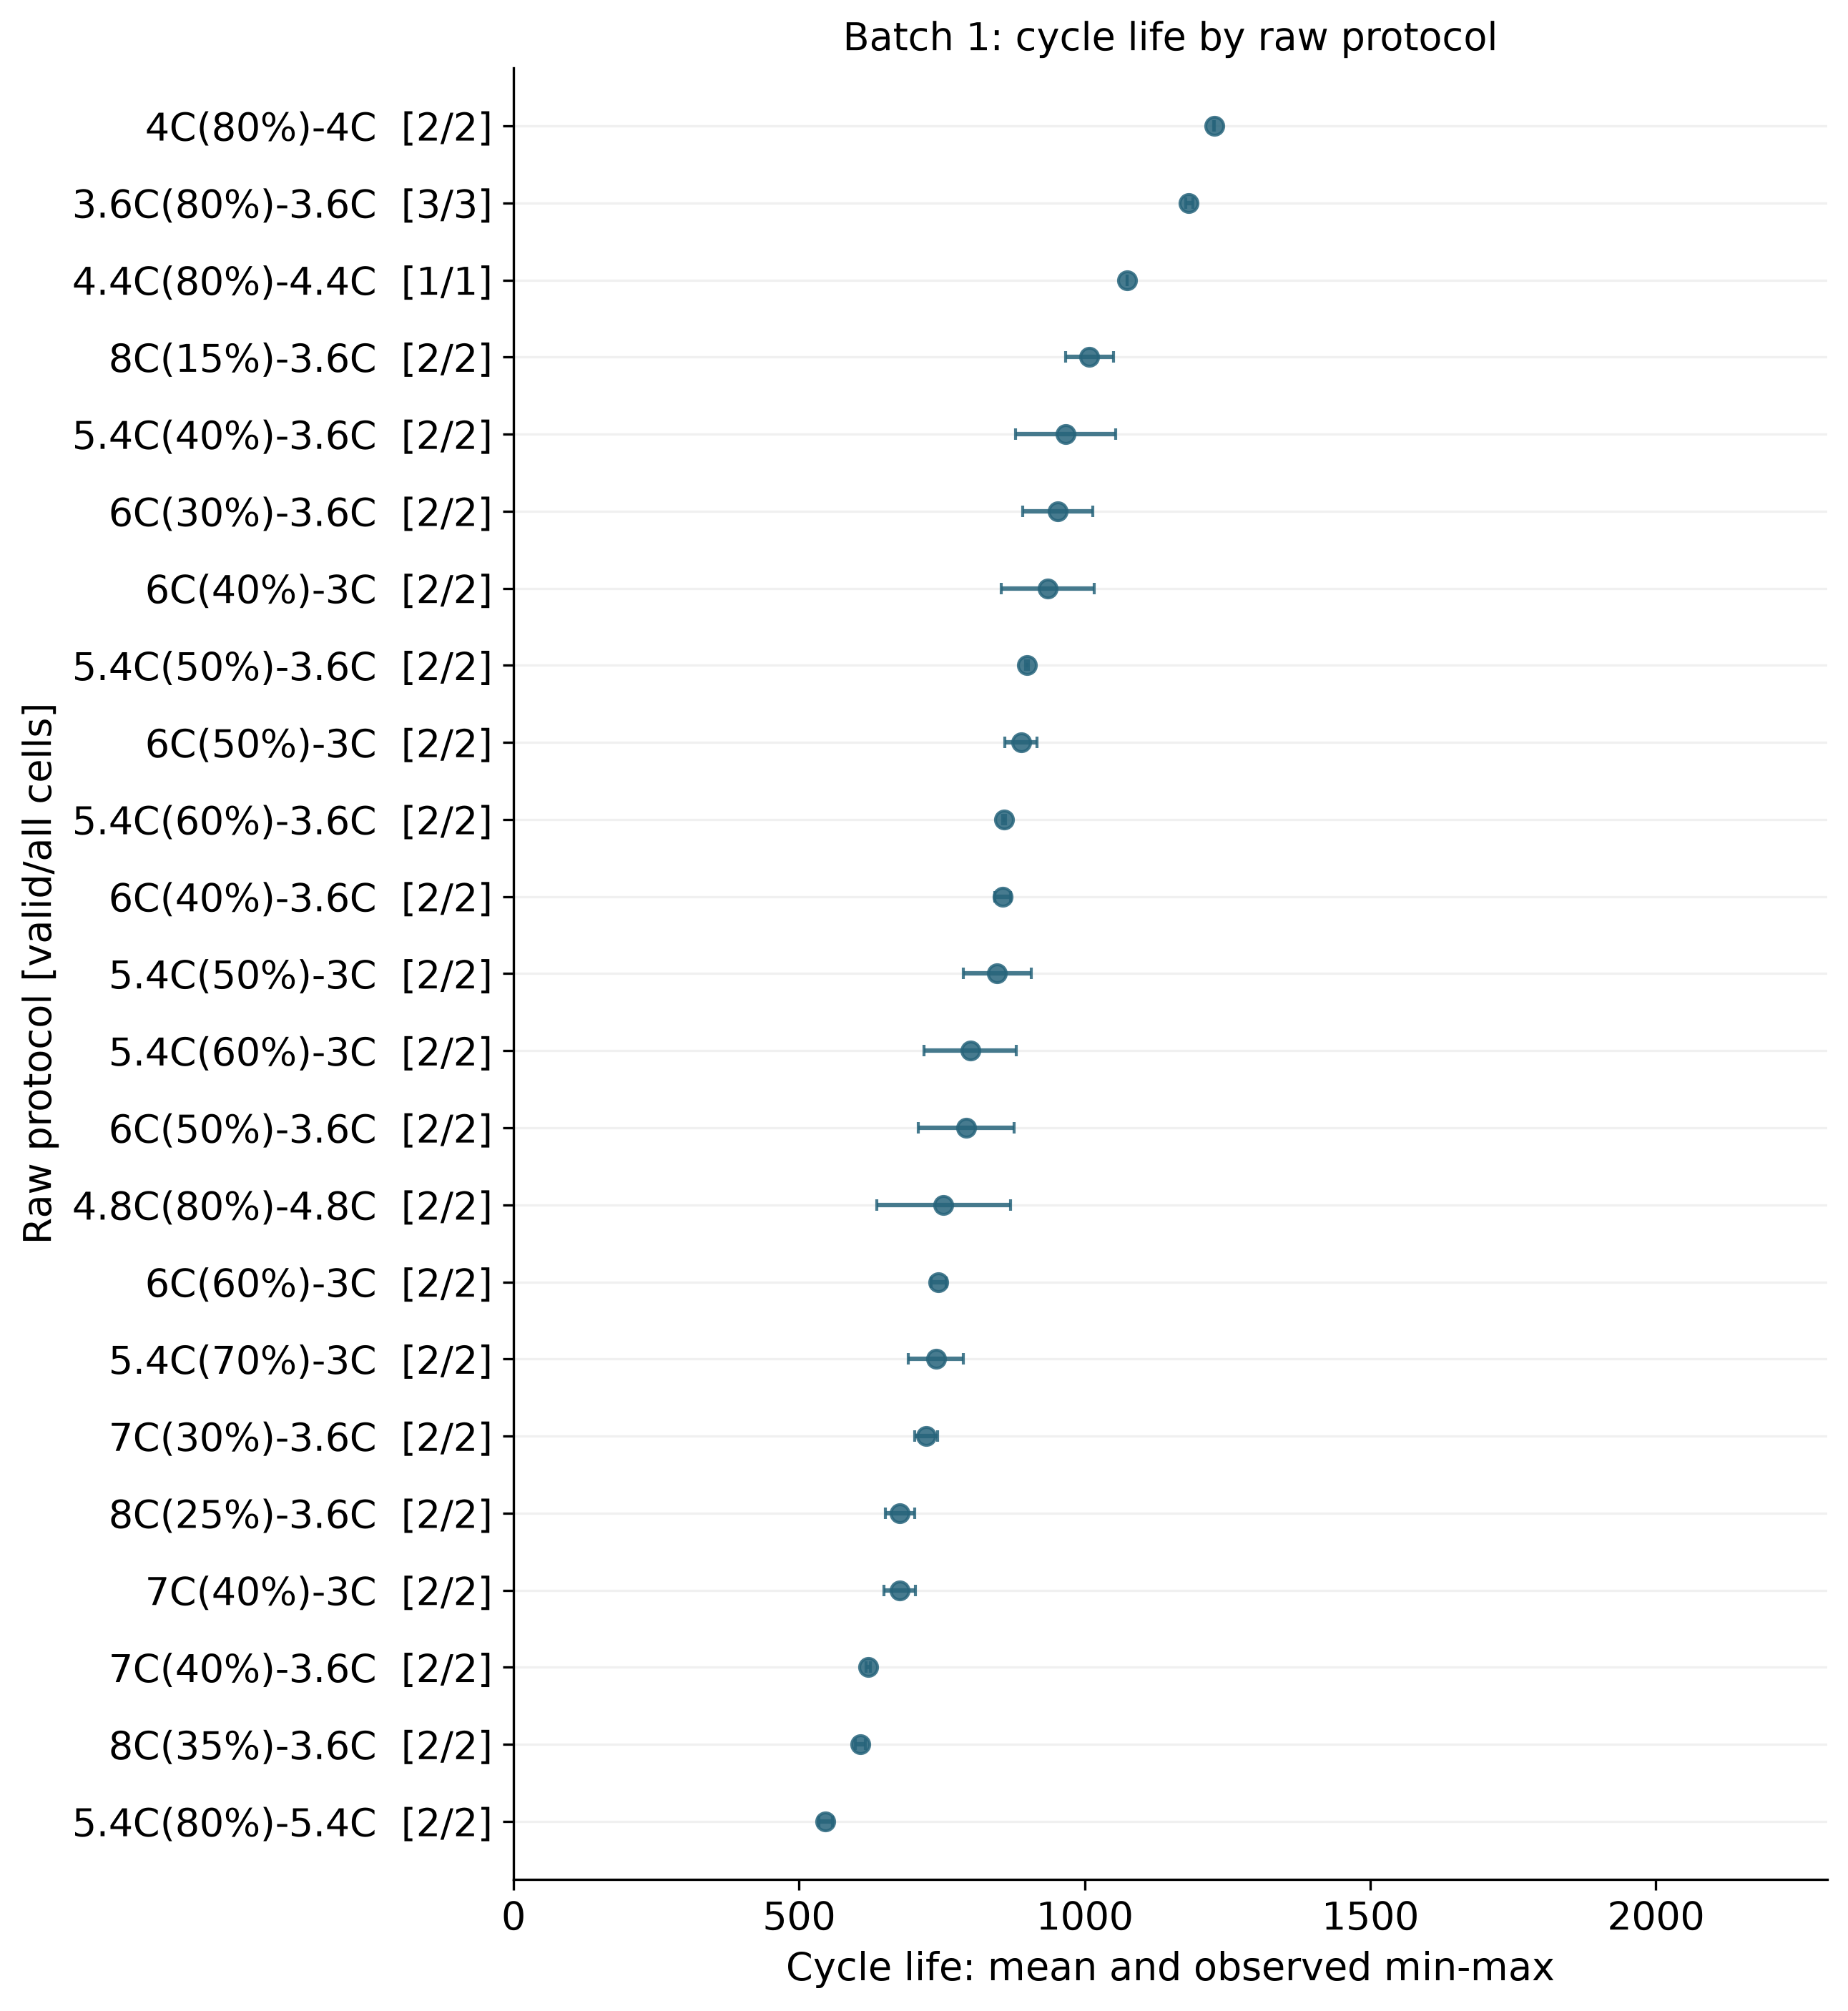

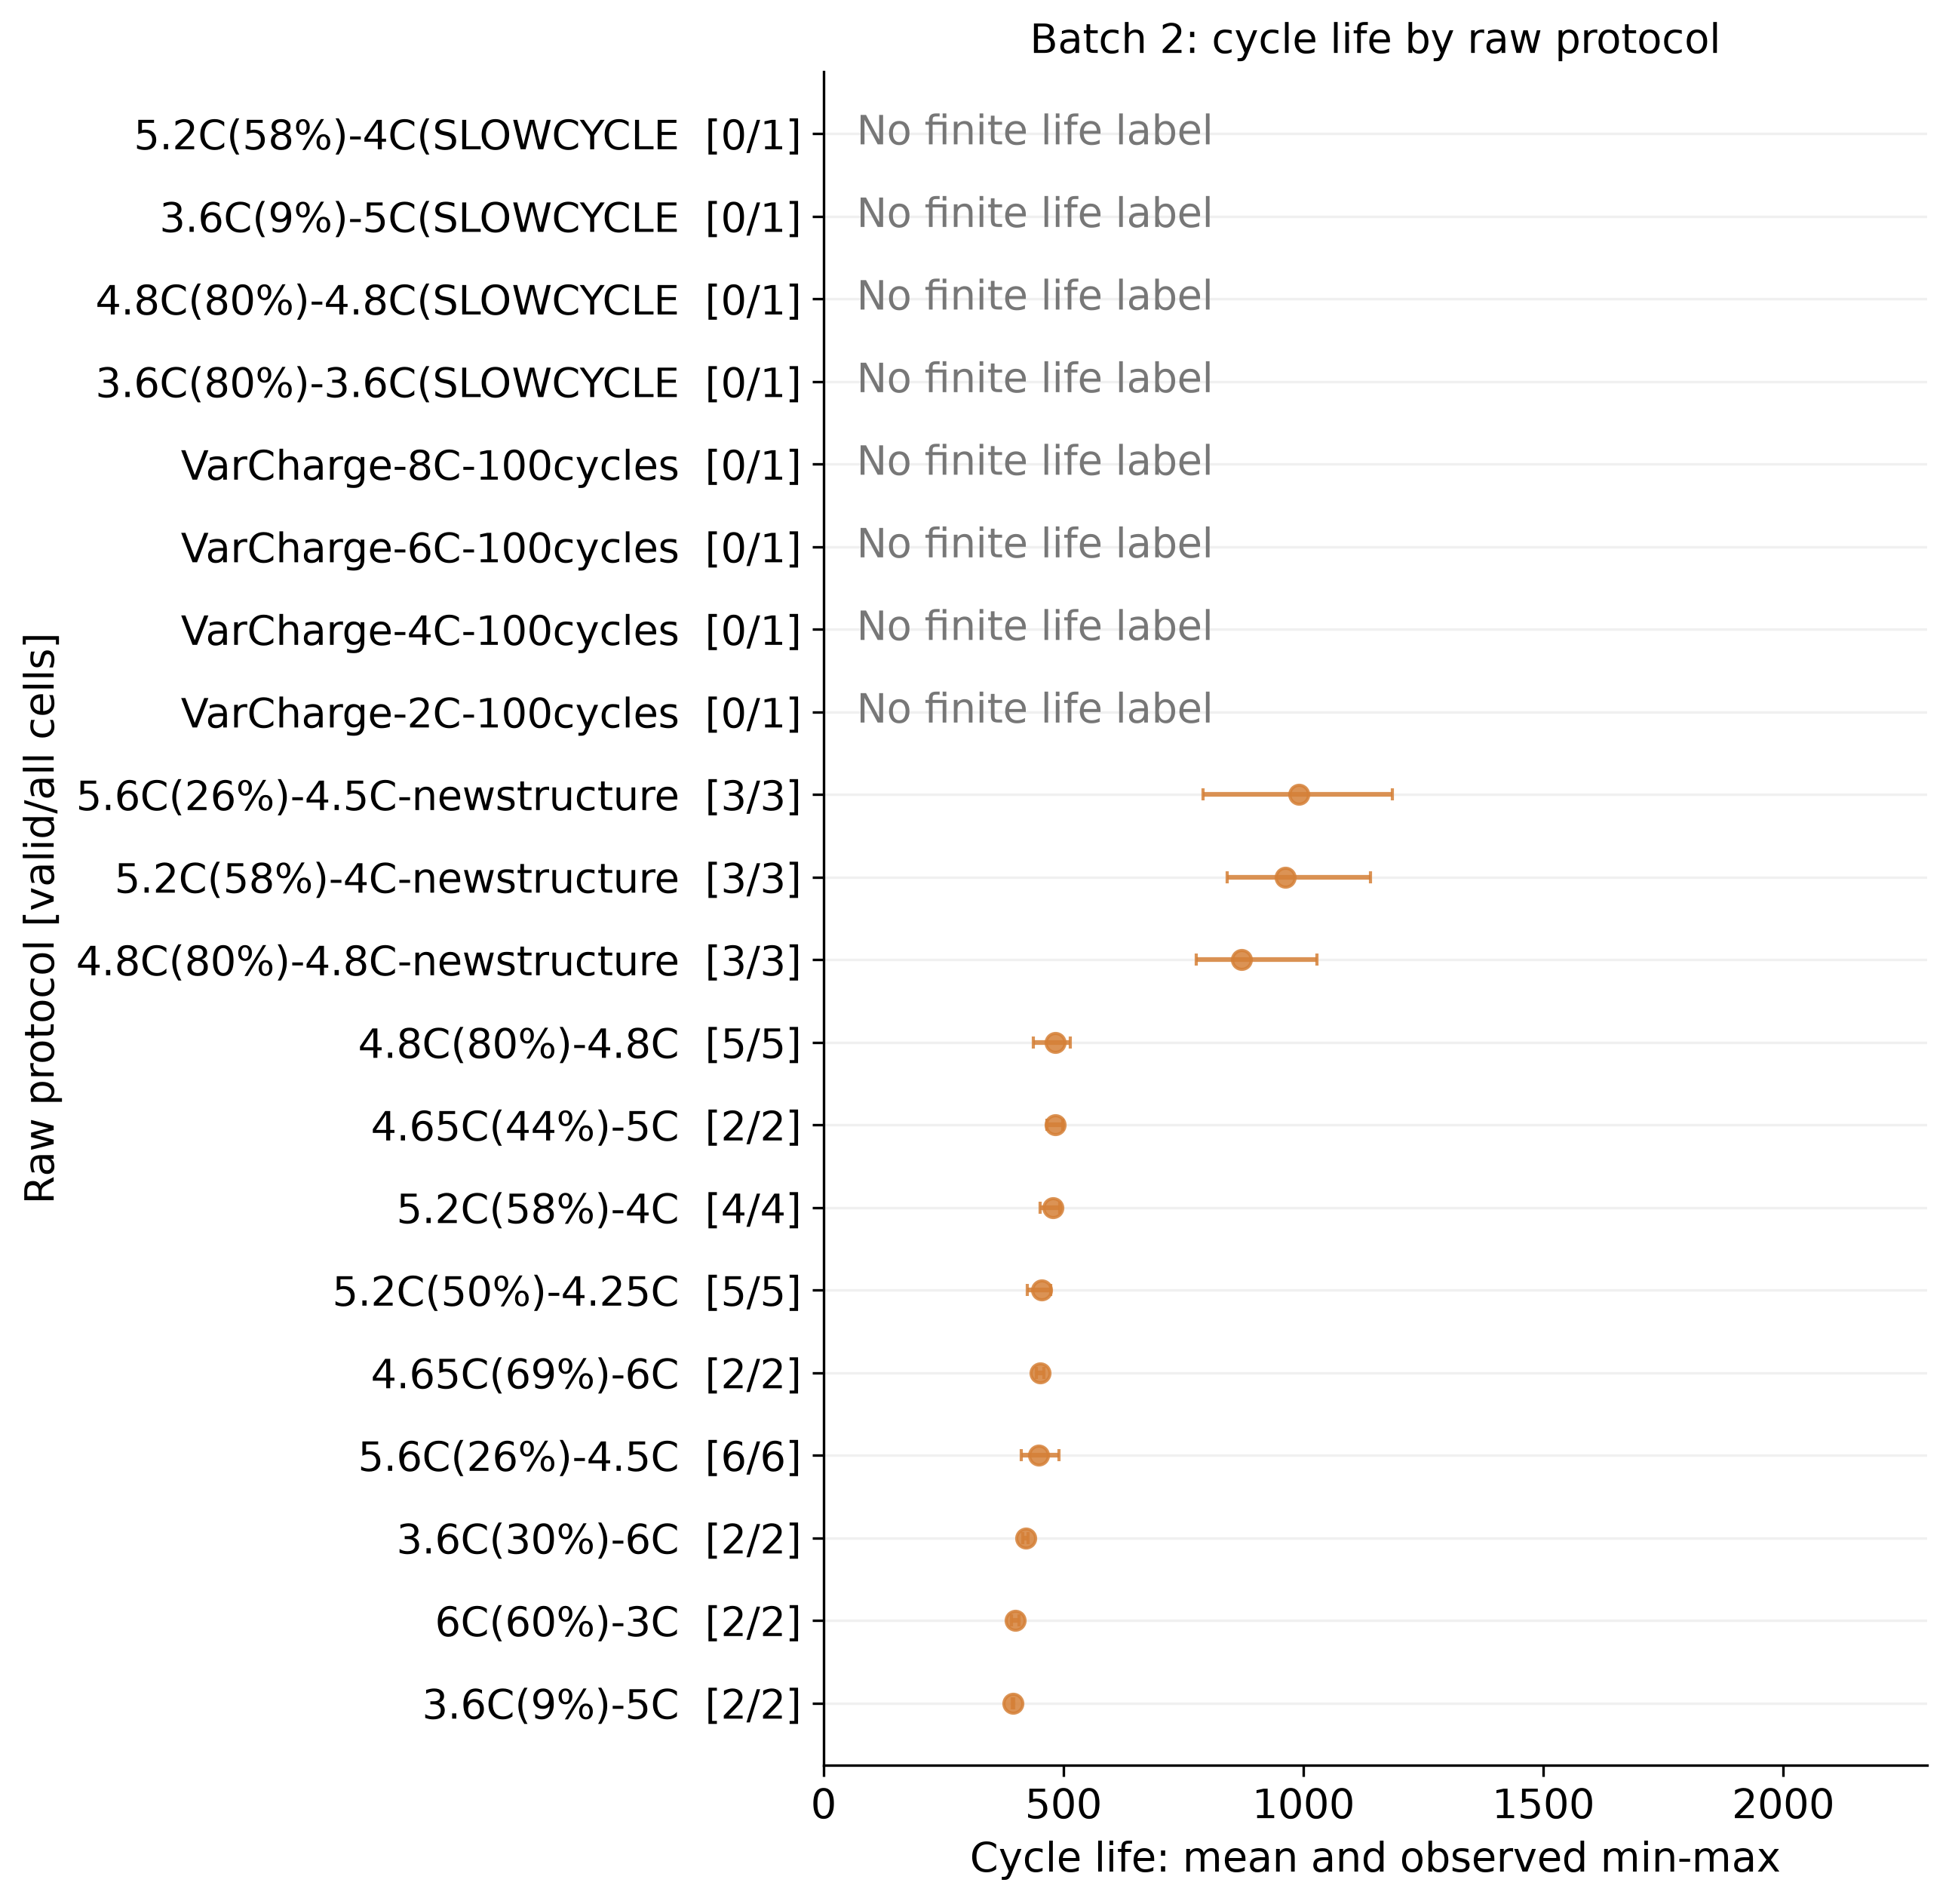

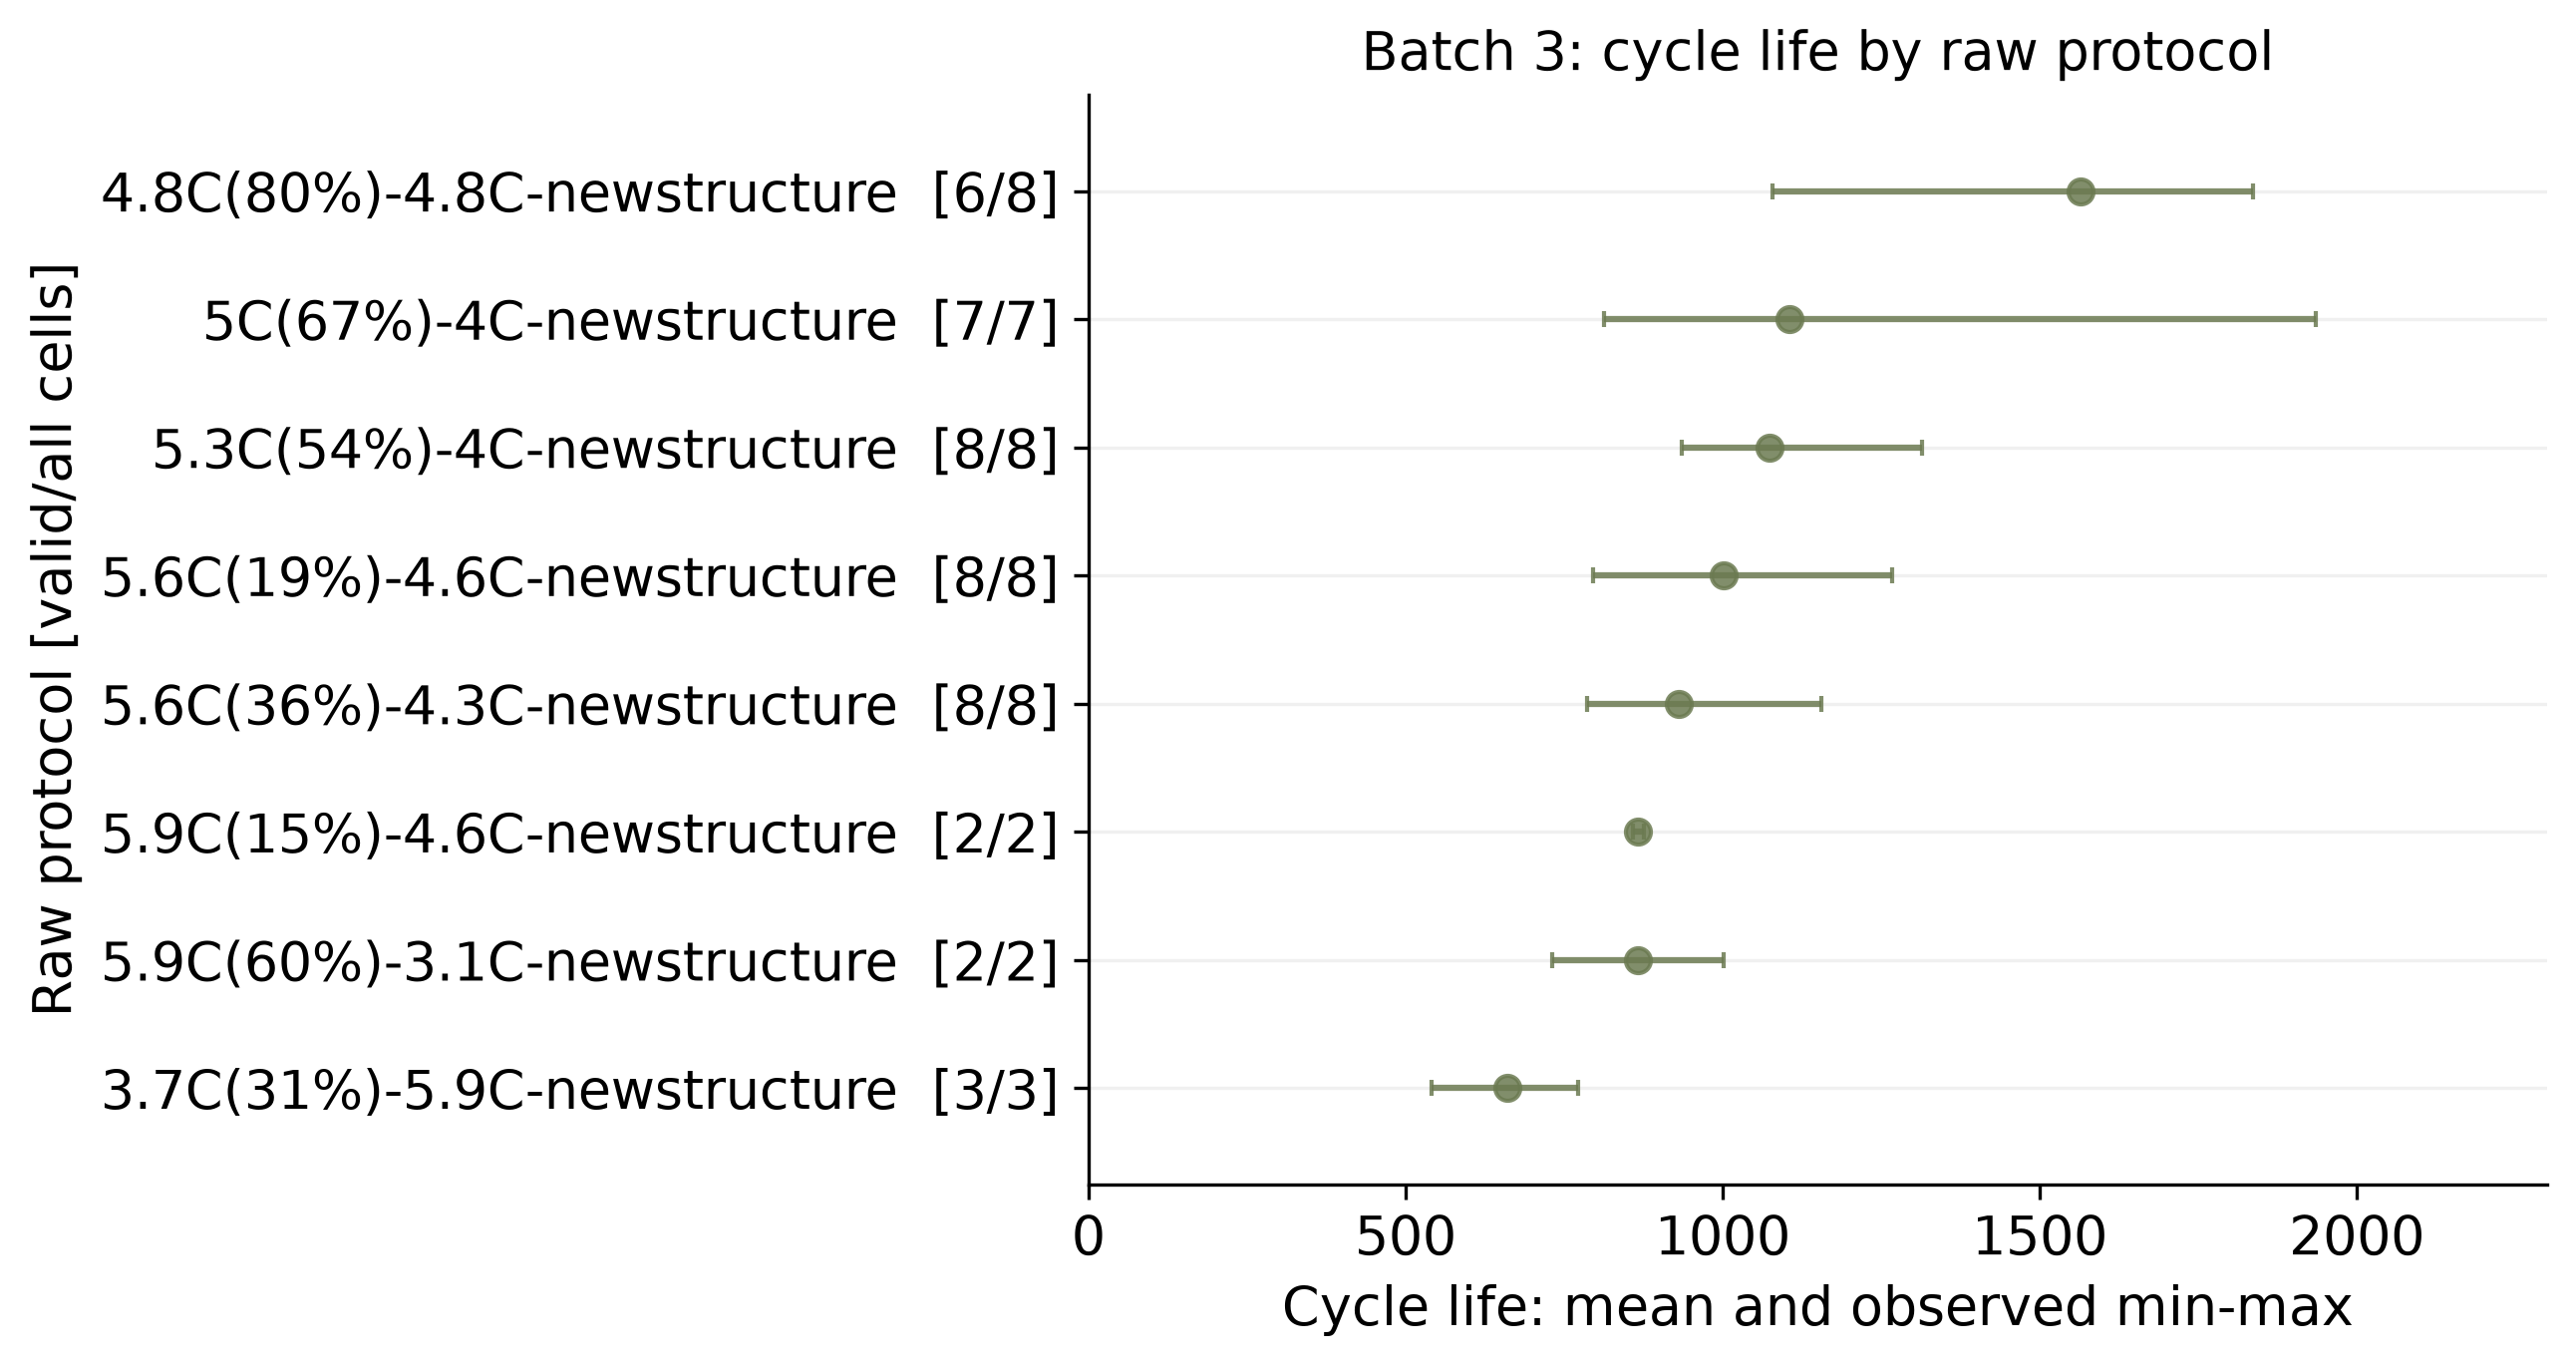

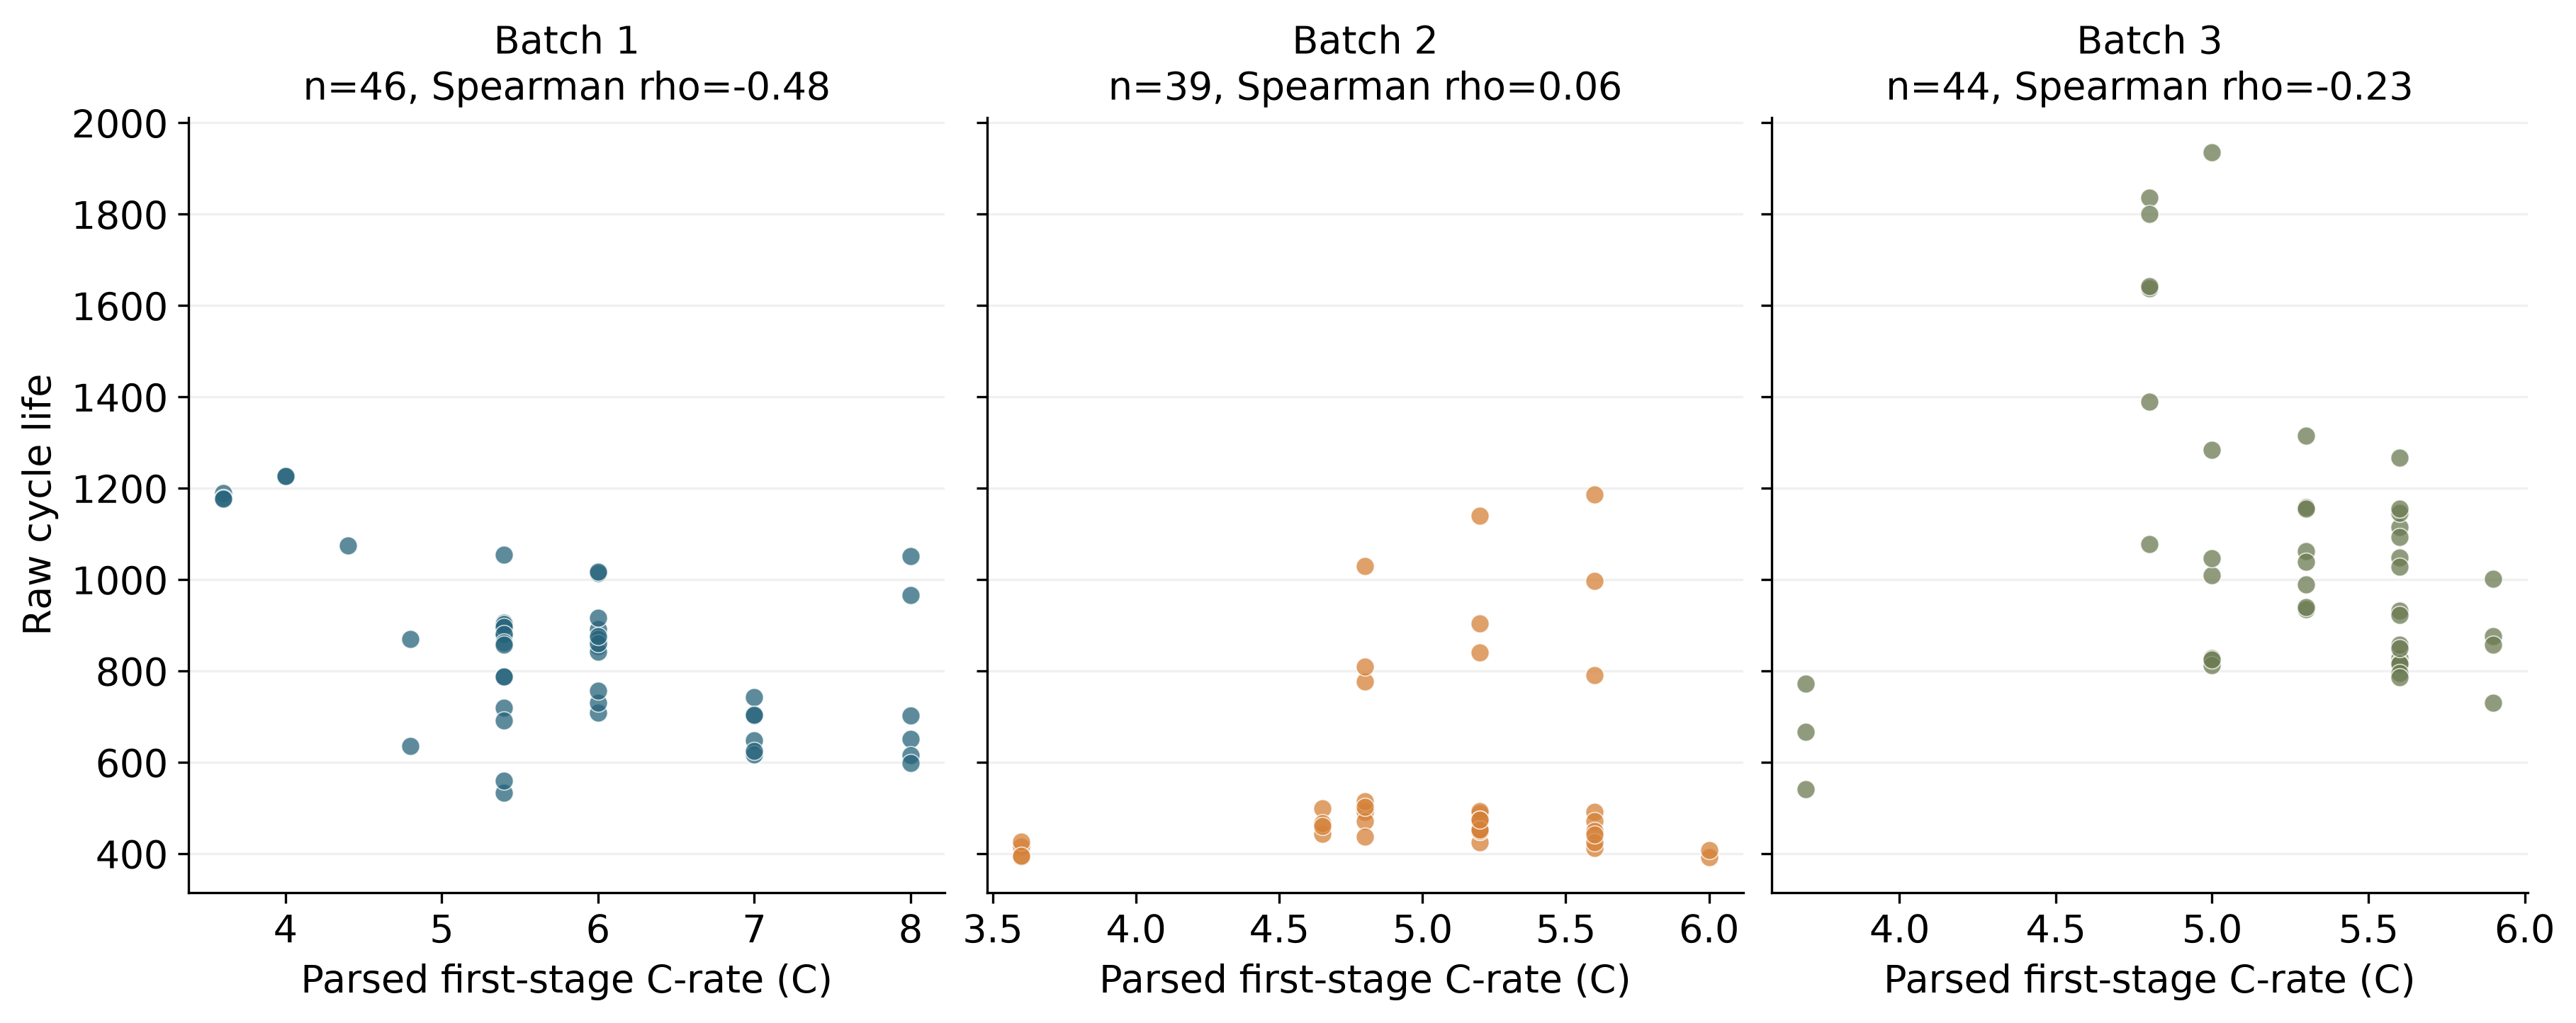

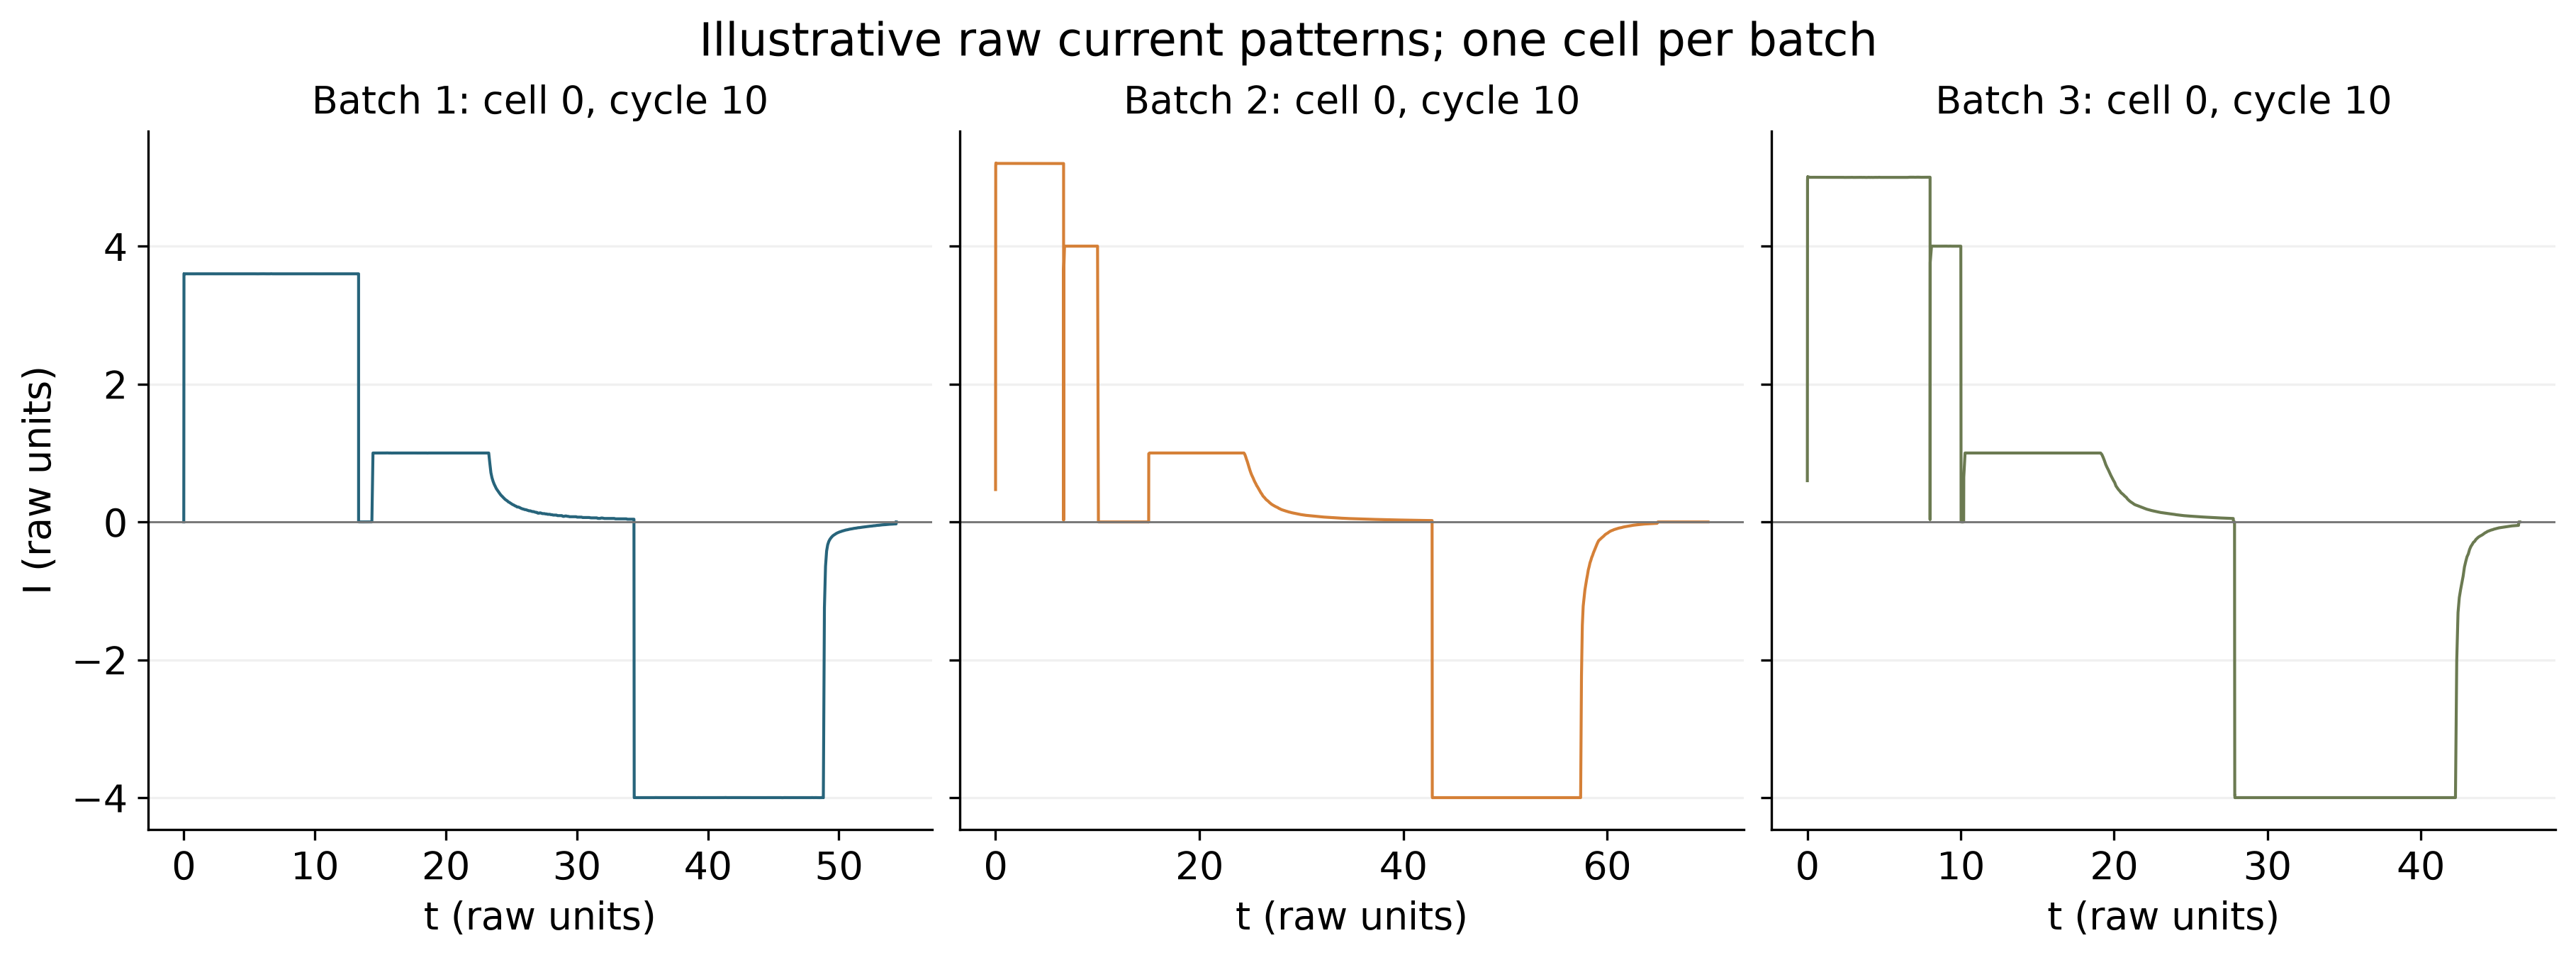

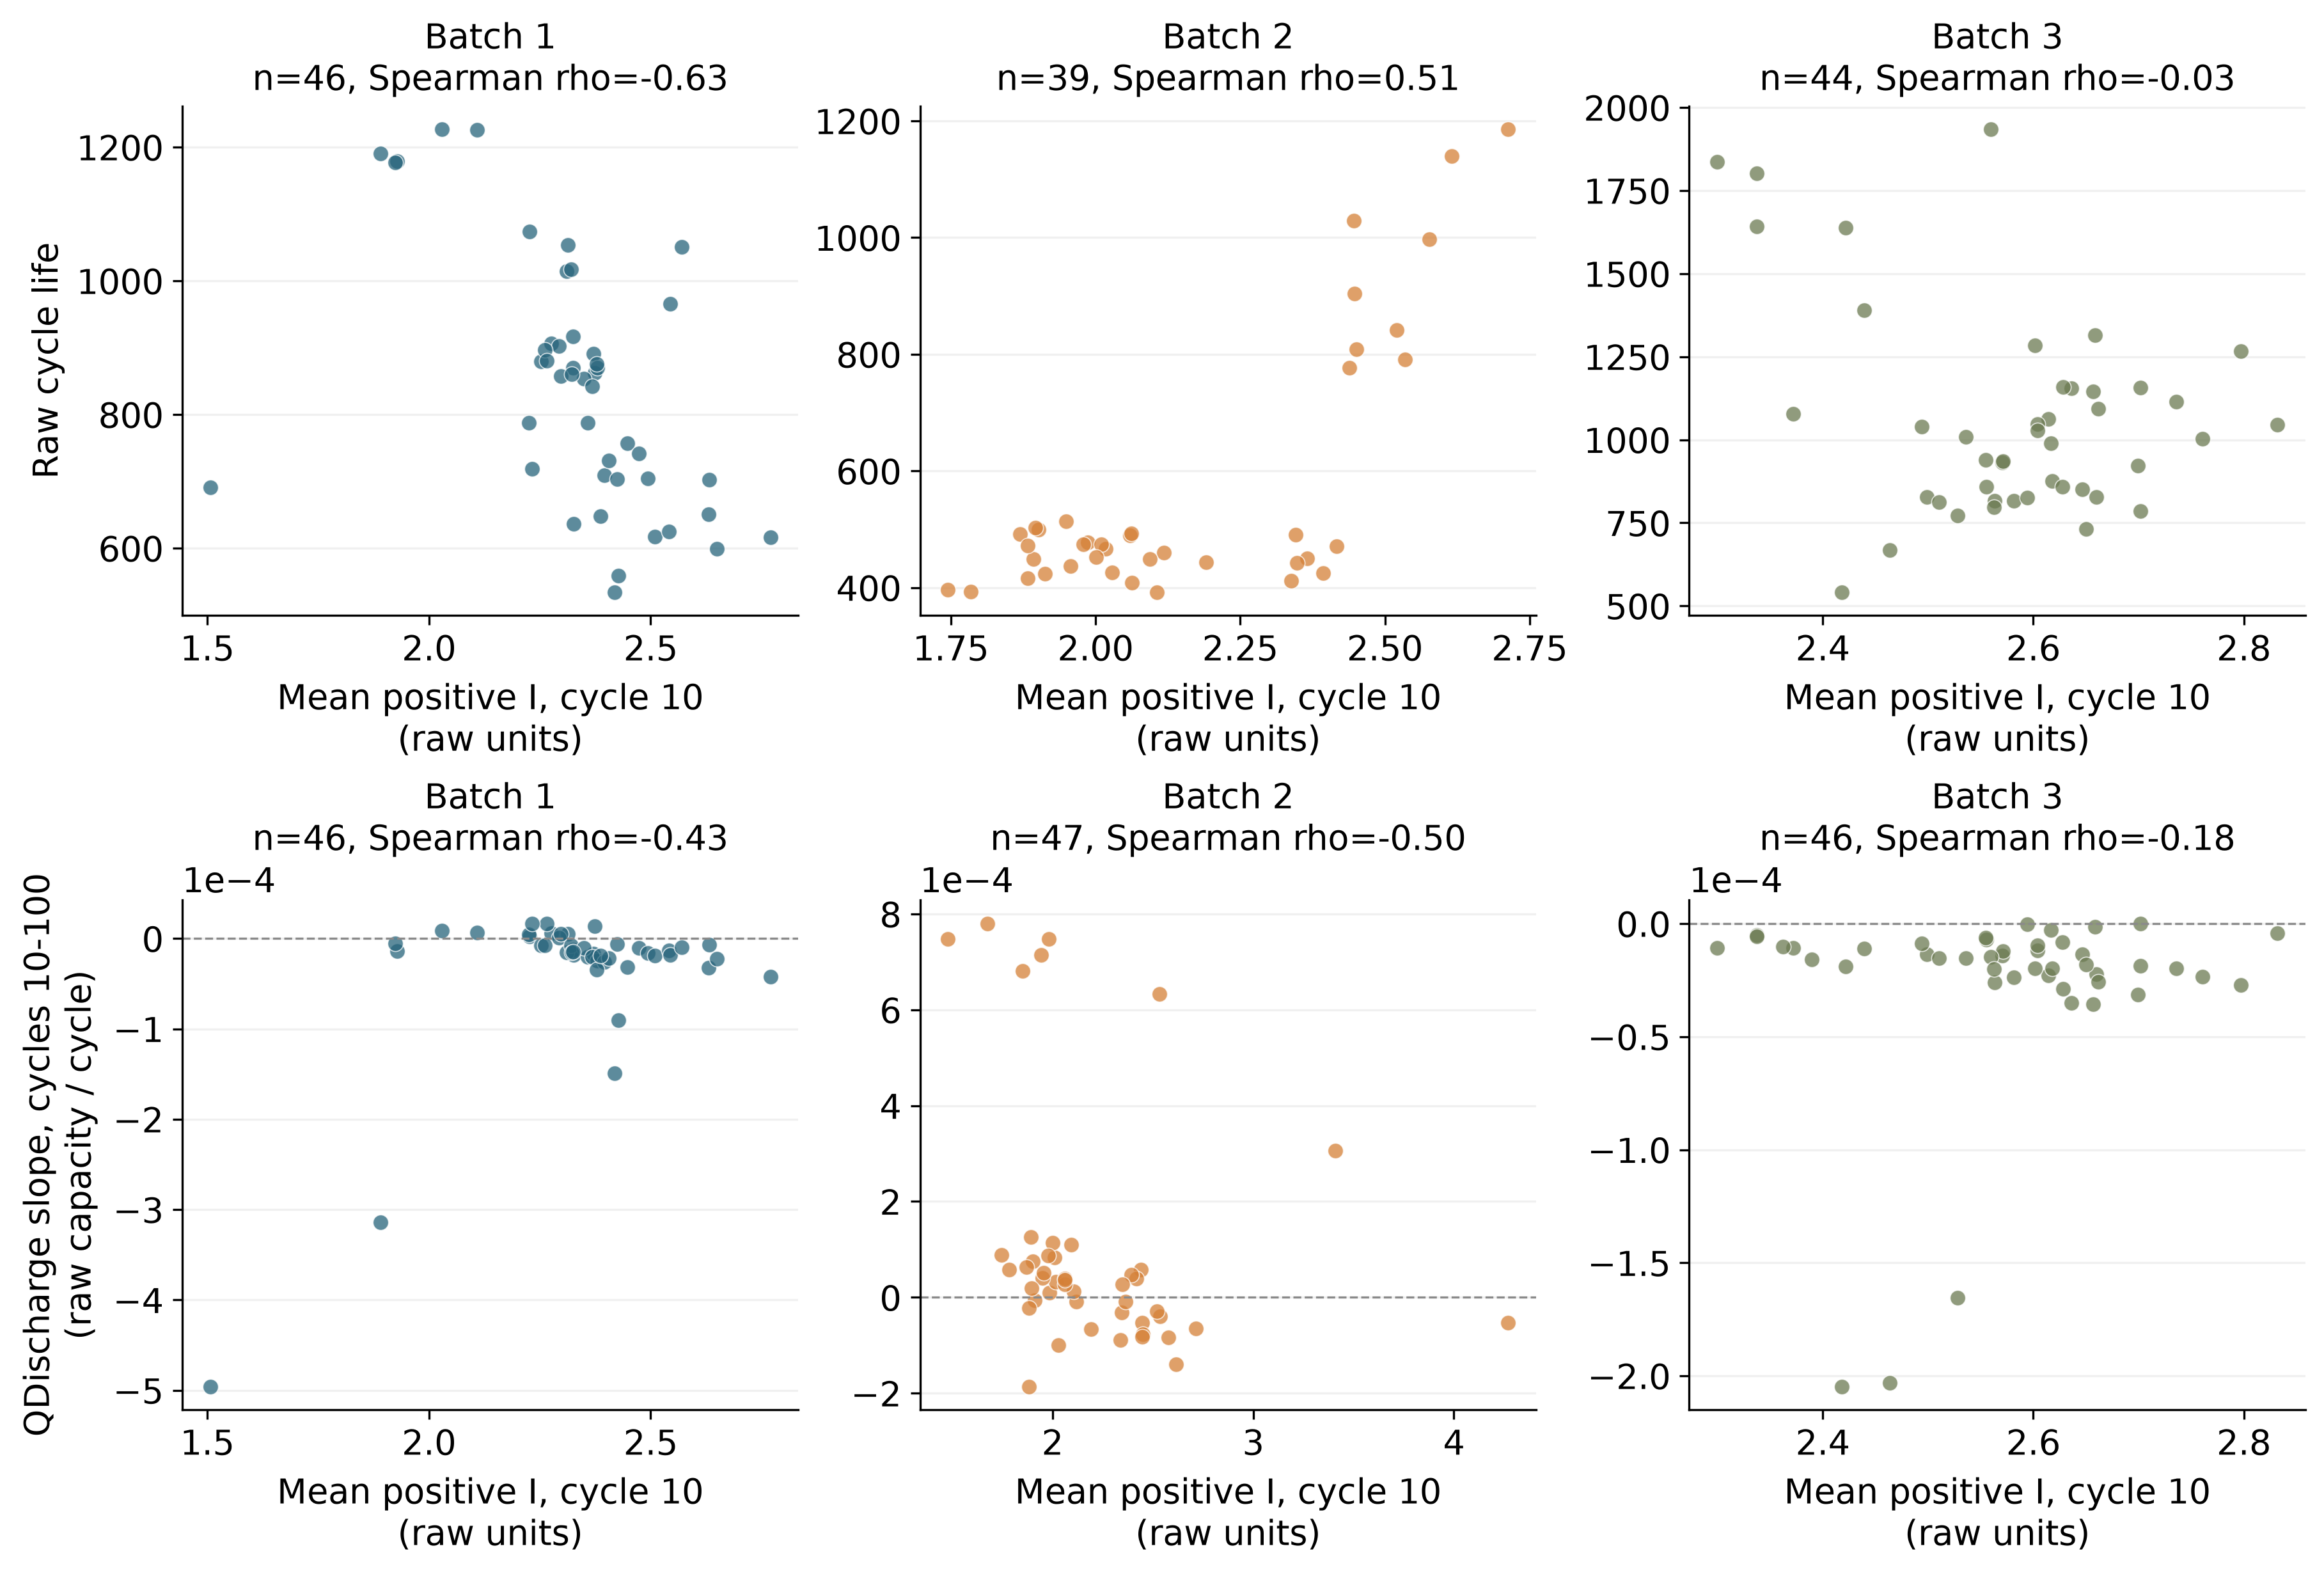

,scope,x,y,n_pairs,pearson_r,pearson_p,spearman_rho,spearman_p
0,all,C1,cycle_life,129,-0.078252,3.780628e-01,-0.027452,7.574591e-01
1,all,SOCswitch,cycle_life,129,0.221584,1.161366e-02,0.160469,6.927433e-02
2,all,C2,cycle_life,129,-0.124814,1.587370e-01,-0.145811,9.918758e-02
3,all,positive_current_mean,cycle_life,129,0.412714,1.171733e-06,0.435945,2.418654e-07
4,all,positive_current_max,cycle_life,129,-0.308511,3.750037e-04,-0.248745,4.475835e-03
5,all,C1,qd_slope_cycle10_100,135,-0.117273,1.755468e-01,-0.219324,1.059383e-02
6,all,SOCswitch,qd_slope_cycle10_100,135,0.045703,5.986400e-01,0.160751,6.252906e-02
7,all,C2,qd_slope_cycle10_100,135,-0.026448,7.607527e-01,-0.061140,4.811644e-01
8,all,positive_current_mean,qd_slope_cycle10_100,139,-0.244794,3.680356e-03,-0.459377,1.283421e-08
9,all,positive_current_max,qd_slope_cycle10_100,139,-0.301974,3.029240e-04,-0.378940,4.224121e-06


In [8]:
display(pd.DataFrame(q1_q4['protocol_parse_counts']))
display(pd.DataFrame(q1_q4['protocol_summary']))
for name in ('q4_protocol_means_batch1.png','q4_protocol_means_batch2.png',
             'q4_protocol_means_batch3.png','q4_c1_life_relationship.png',
             'q4_current_patterns_cell0.png','q4_current_life_slope.png'):
    show_figure(name)
display(pd.DataFrame(q1_q4['correlations']))

**관찰:** 양의 전류 표본 평균과 수명의 Spearman 상관은 전체 +0.436이지만
Batch 1 -0.628, Batch 2 +0.506, Batch 3 -0.026으로 방향이 일정하지 않다.
전류 평균과 초기 Qd 기울기 상관도 전체 -0.459, Batch 1 -0.433, Batch 2 -0.497, Batch 3 -0.177이다.

**해석:** 프로토콜별 평균은 작은 그룹 표본과 배치 차이의 영향을 받는다.
특정 충전 전류가 수명을 줄인다는 인과 결론을 이 비교만으로 낼 수 없다.
전류의 단위와 샘플링·충전 구간 정의를 확인한 뒤 물리량을 해석해야 한다.

**시사점:** 단일 C1만으로 수명을 결정하지 않는다. 프로토콜 구성요소는 추가 피처 후보로 검토하며,
같은 프로토콜의 셀들이 검증 양쪽에 섞이는 정도를 점검한다.

## 5. 초기 신호와 상관관계 — 정보가 강한가, 중복되는가?

초기 용량·IR·온도·충전시간과 ΔQ 통계의 Pearson/Spearman 상관을 셀 단위로 확인한다.
원본 `cycle_life`를 사용하며 타깃 결측은 해당 상관 계산에서만 빠진다.
전체 상관과 배치 내부 상관을 구분하고 피처의 결측·0도 함께 기록한다.

scope,batch1,batch2,batch3,pooled
feature,,,,
charge_time_mean10_100,0.616689,-0.390829,0.201776,-0.128414
delta_ir100_10,-0.240286,0.115044,-0.312566,-0.037915
delta_q_log10var,-0.871161,-0.708979,-0.797237,-0.892074
delta_q_mean,0.828112,0.697237,0.756149,0.869274
delta_q_min,0.850006,0.660897,0.776024,0.883398
delta_q_range,-0.849513,-0.649863,-0.673409,-0.868318
delta_q_var,-0.871161,-0.708979,-0.797237,-0.892074
delta_qd100_10,0.612619,-0.054560,0.031503,-0.086727
ir10,0.214506,-0.385997,0.162027,-0.334061


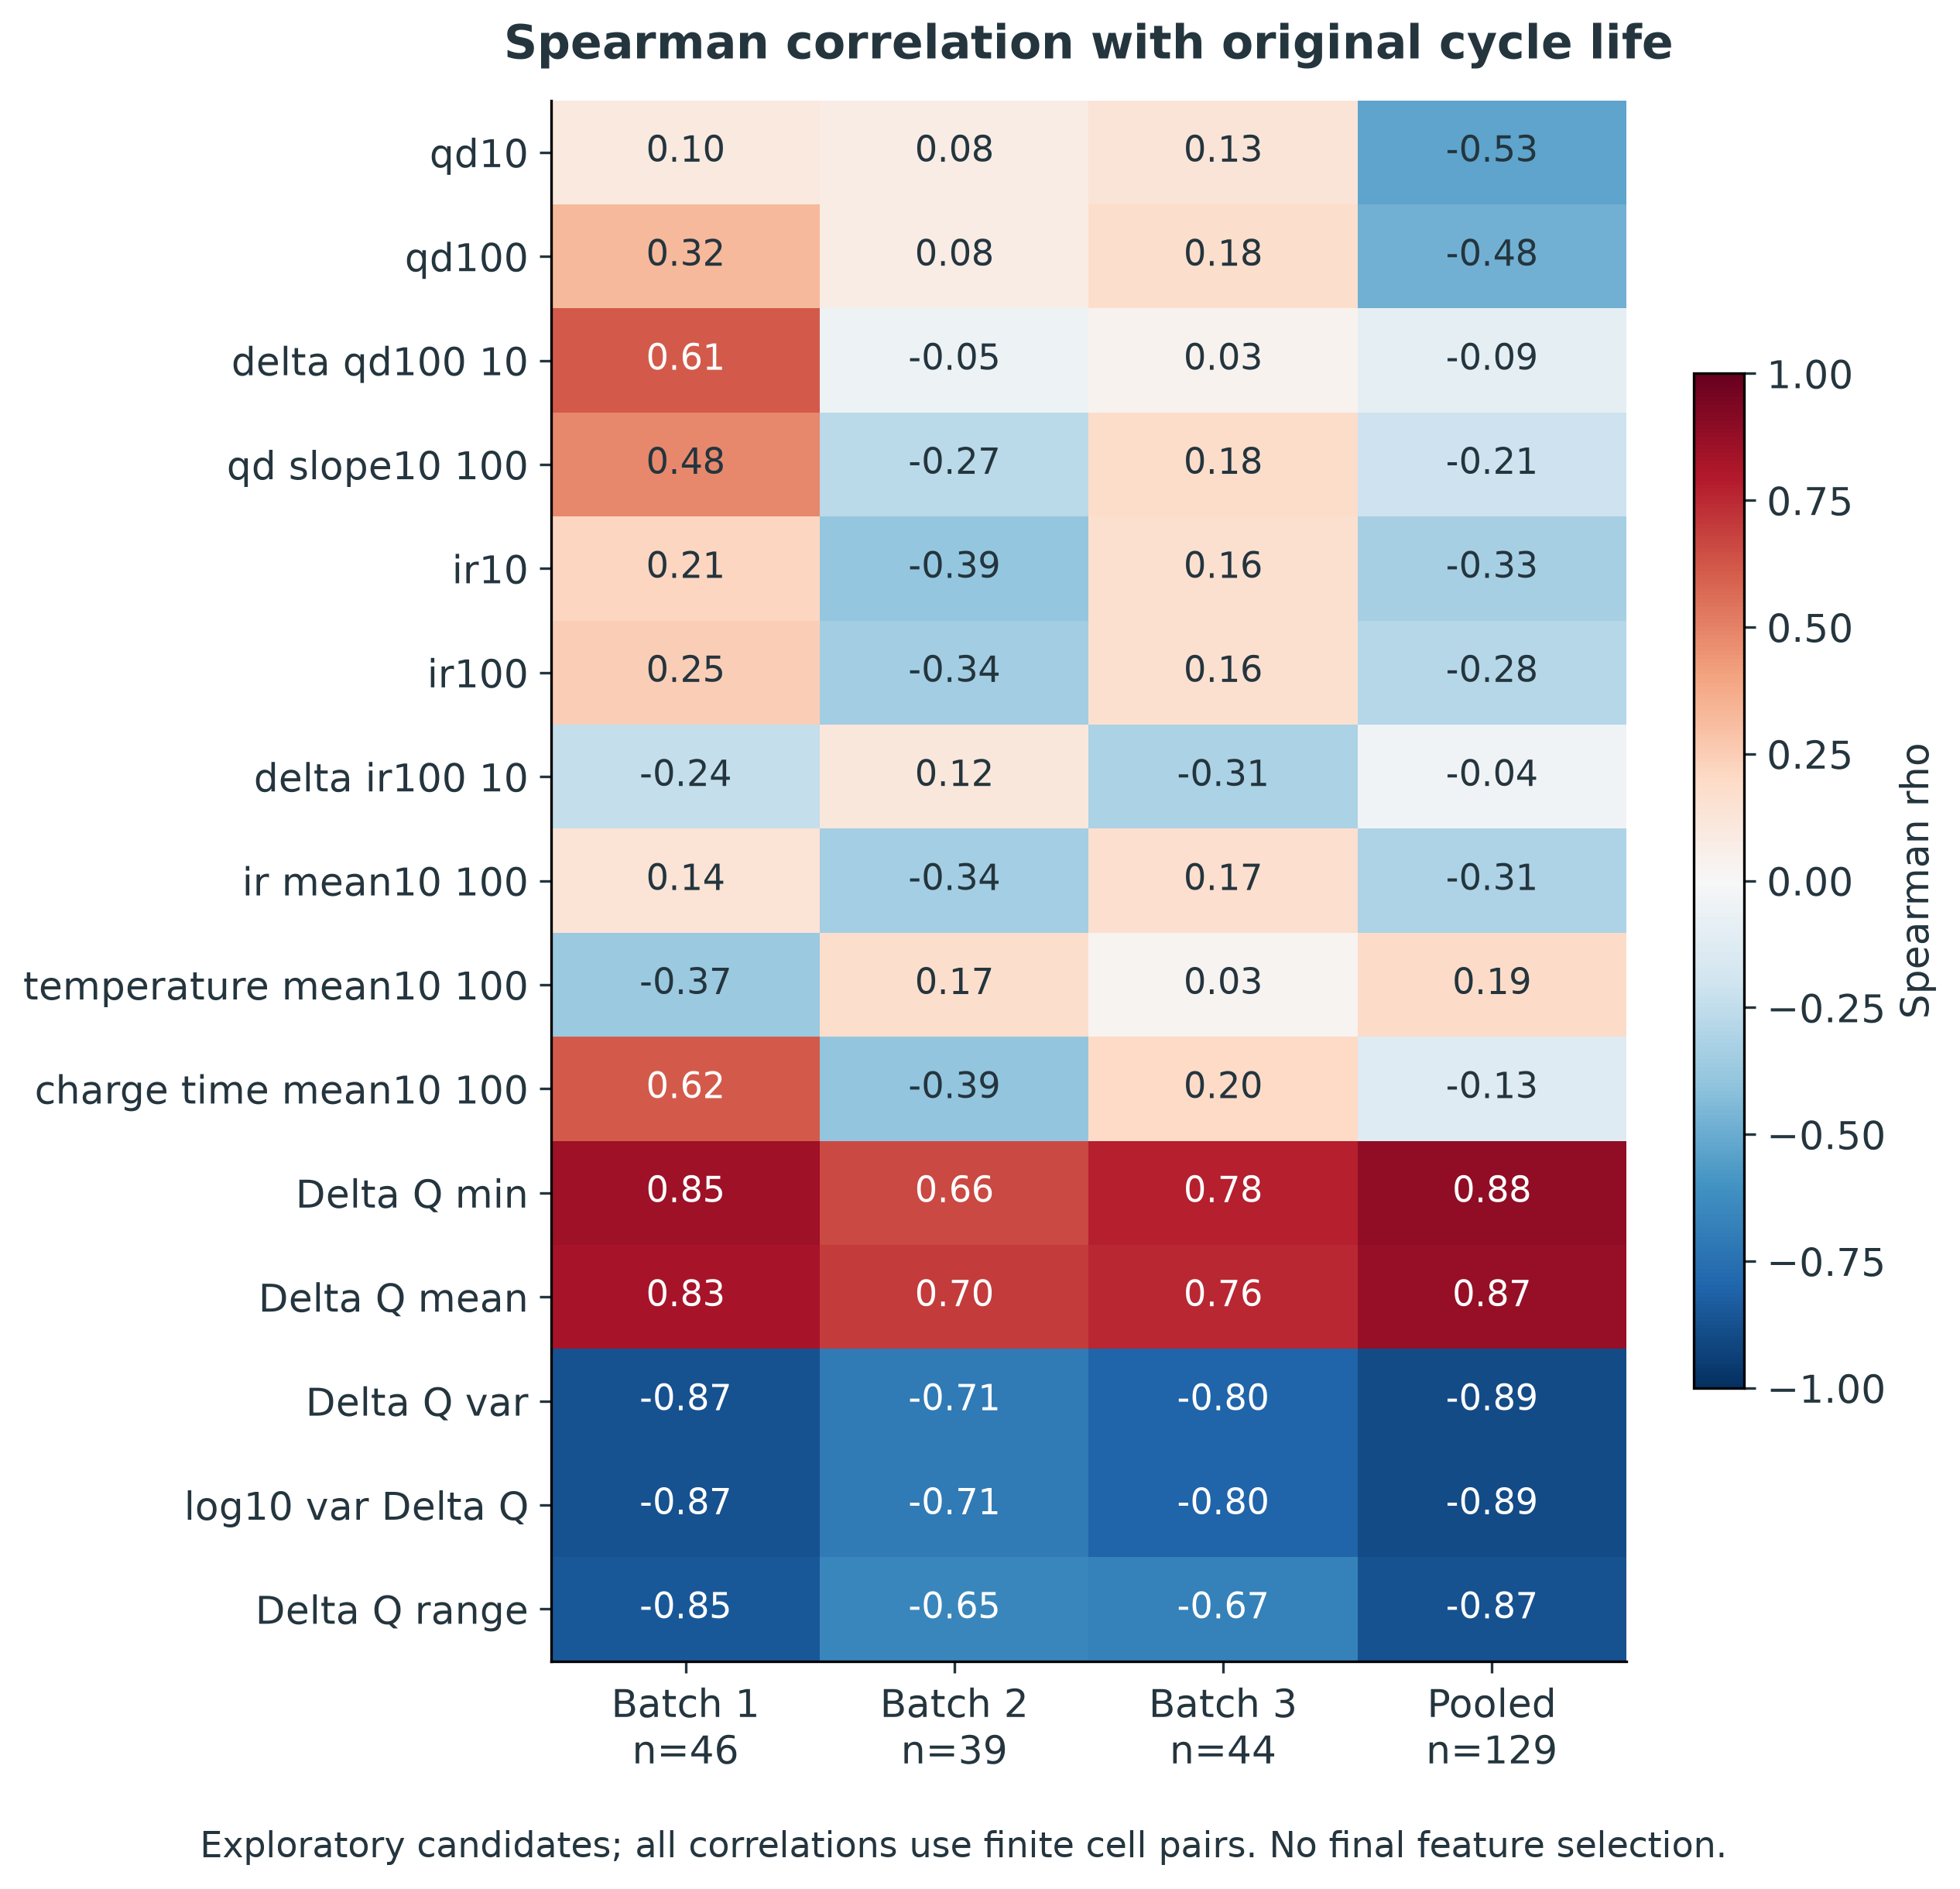

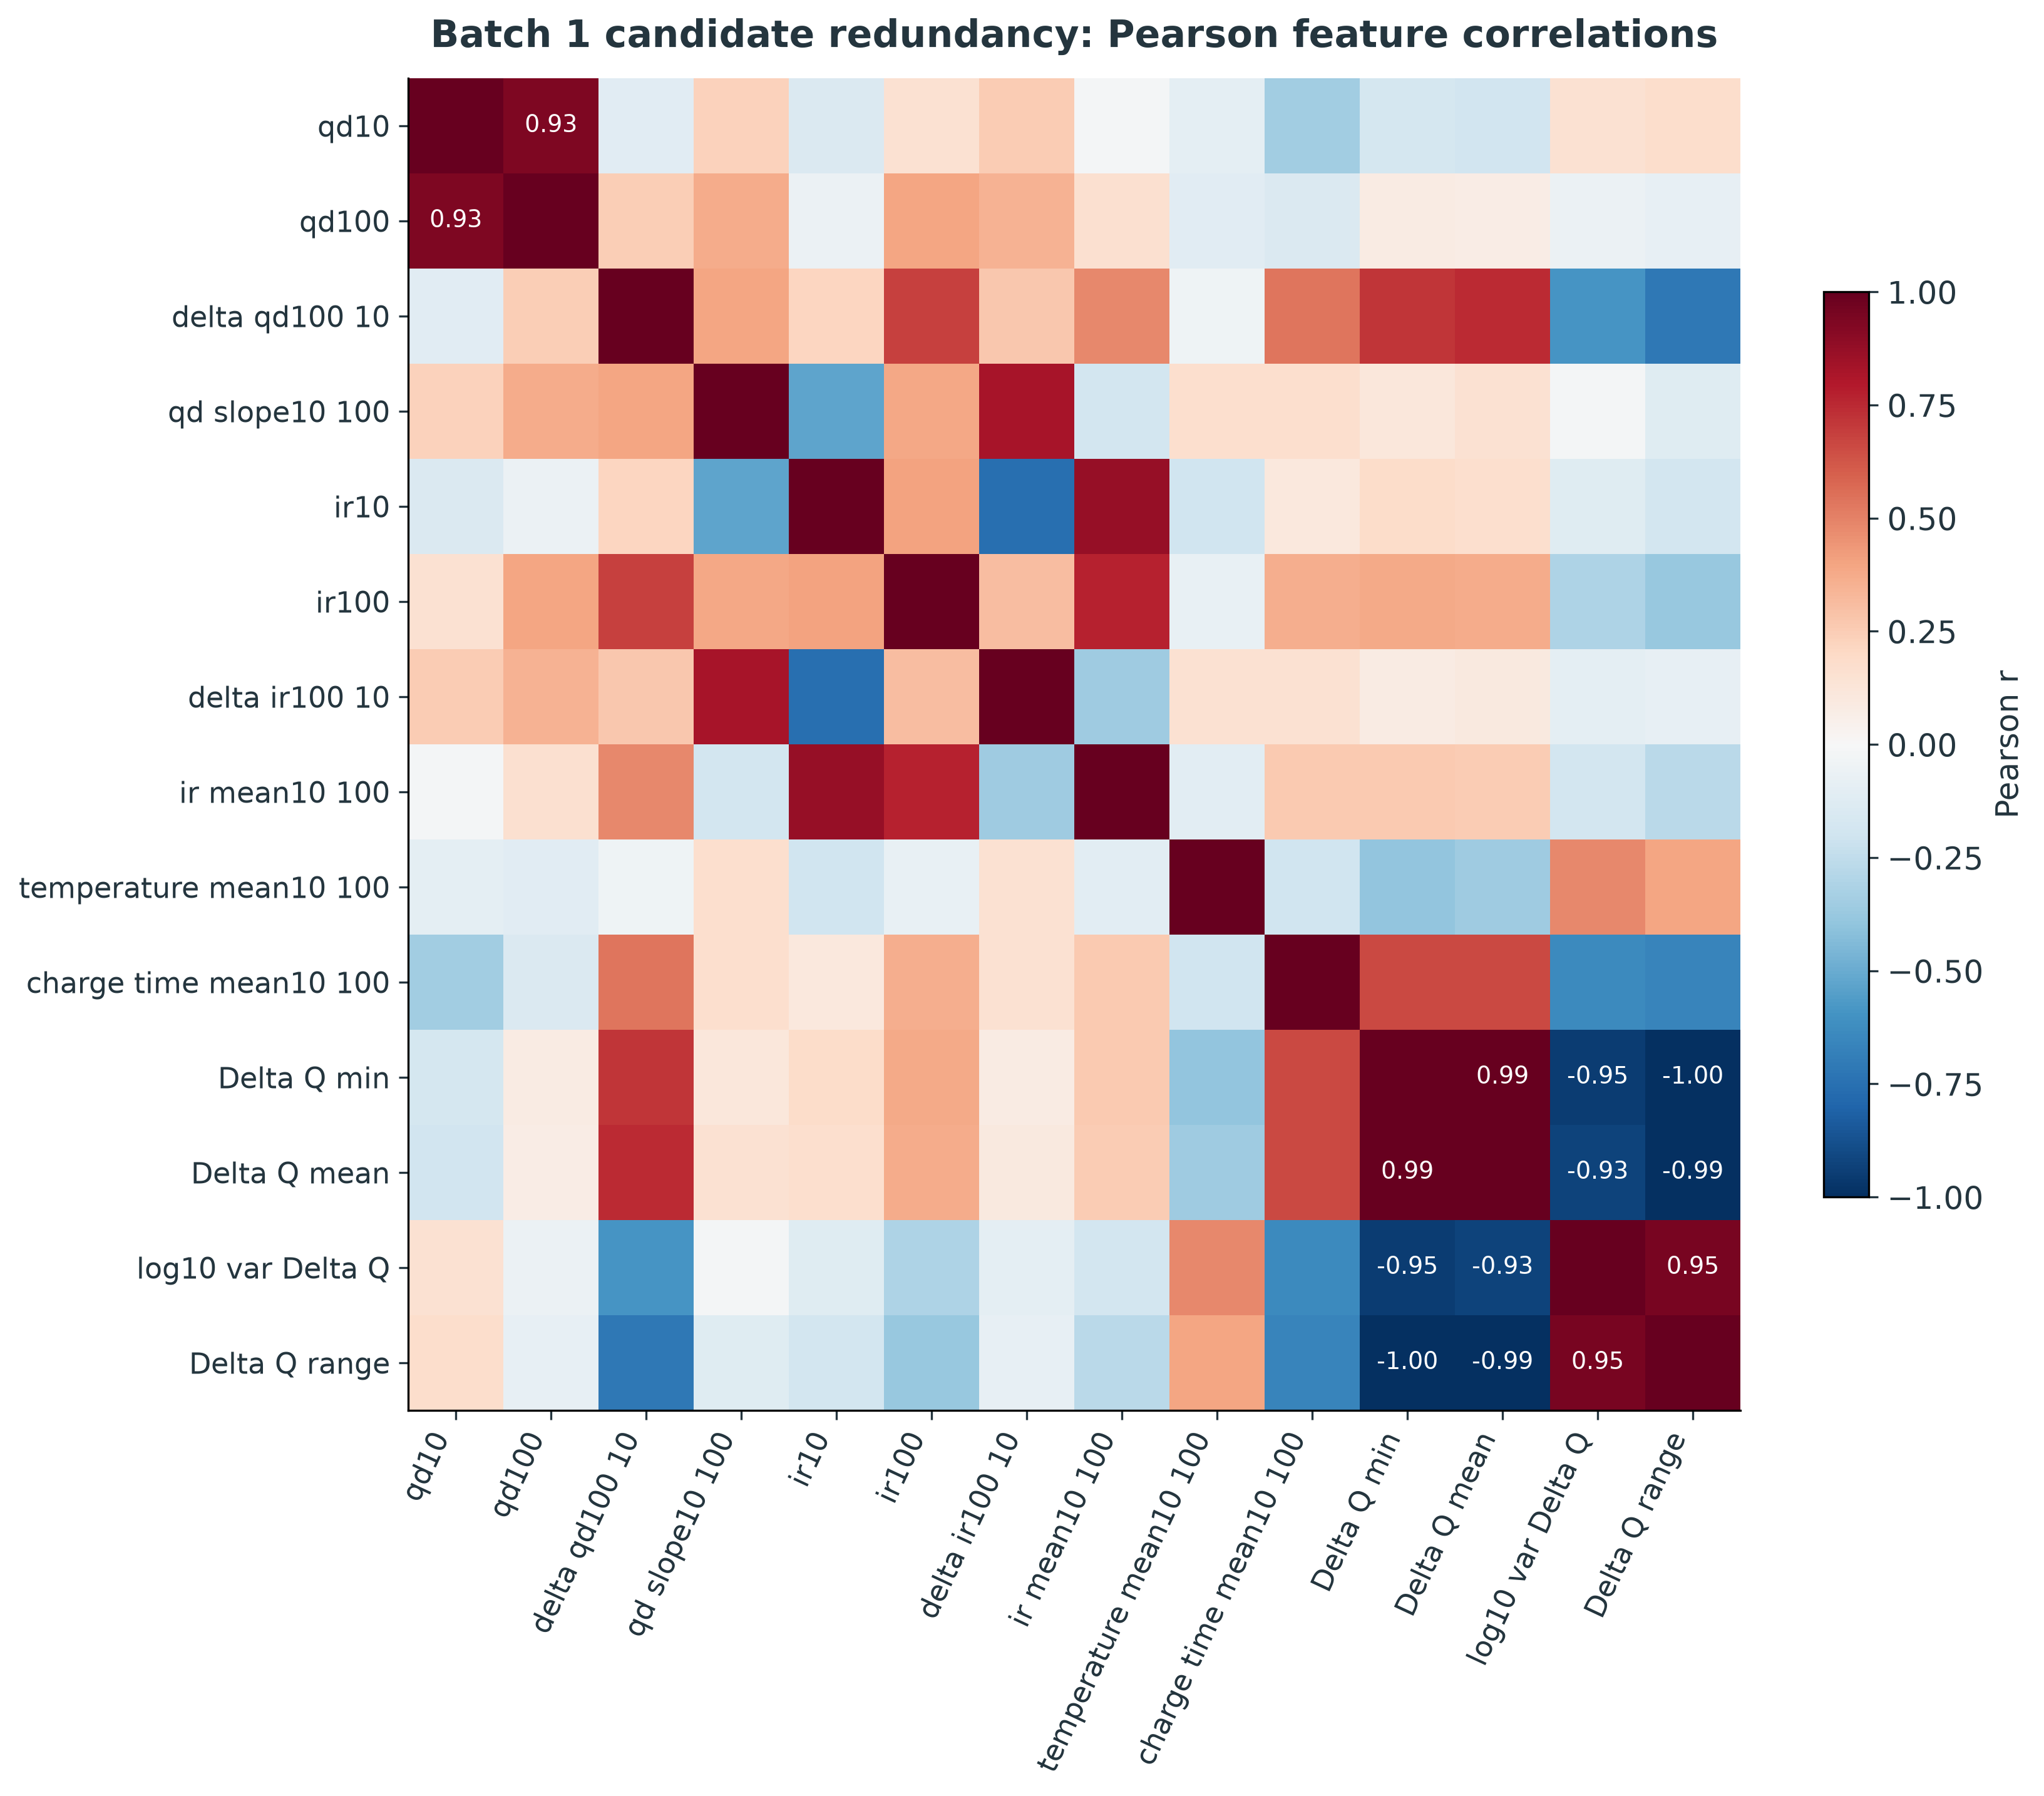

{'batch1': {'n_cells': 46,
  'qv_availability': {'available': 92},
  'qv_cell_checks': [{'cell_id': 0,
    'cycle10_points': 1000,
    'cycle100_points': 1000,
    'exact_grid_match': True,
    'finite_curve': True,
    'status': 'available'},
   {'cell_id': 1,
    'cycle10_points': 1000,
    'cycle100_points': 1000,
    'exact_grid_match': True,
    'finite_curve': True,
    'status': 'available'},
   {'cell_id': 2,
    'cycle10_points': 1000,
    'cycle100_points': 1000,
    'exact_grid_match': True,
    'finite_curve': True,
    'status': 'available'},
   {'cell_id': 3,
    'cycle10_points': 1000,
    'cycle100_points': 1000,
    'exact_grid_match': True,
    'finite_curve': True,
    'status': 'available'},
   {'cell_id': 4,
    'cycle10_points': 1000,
    'cycle100_points': 1000,
    'exact_grid_match': True,
    'finite_curve': True,
    'status': 'available'},
   {'cell_id': 5,
    'cycle10_points': 1000,
    'cycle100_points': 1000,
    'exact_grid_match': True,
    'finite_cur

{'pooled': {'n_complete_cells': 139,
  'n_candidate_features': 15,
  'n_nonconstant': 15,
  'standardized_matrix_rank': 13,
  'standardized_condition_number': 1.580550872396984e+16,
  'note': 'Diagnostic only; all candidate features include deliberate algebraic redundancy. No final feature set selected or OLS prediction model fitted.'},
 'batch1': {'n_complete_cells': 46,
  'n_candidate_features': 15,
  'n_nonconstant': 15,
  'standardized_matrix_rank': 13,
  'standardized_condition_number': 3.8718927632983736e+16,
  'note': 'Diagnostic only; all candidate features include deliberate algebraic redundancy. No final feature set selected or OLS prediction model fitted.'},
 'batch2': {'n_complete_cells': 47,
  'n_candidate_features': 15,
  'n_nonconstant': 15,
  'standardized_matrix_rank': 13,
  'standardized_condition_number': 1.7587906638677858e+16,
  'note': 'Diagnostic only; all candidate features include deliberate algebraic redundancy. No final feature set selected or OLS prediction 

In [9]:
correlations = pd.DataFrame(q3_q5['q5']['correlations'])
display(correlations.pivot(index='feature', columns='scope', values='spearman'))
show_figure('q5_target_correlations.png')
show_figure('q5_feature_redundancy.png')
display(q3_q5['quality'])
display({name:{key:value for key,value in result.items()
               if key not in ('pearson_matrix','vif','high_pairs_abs_pearson_ge_0_90')}
         for name,result in q3_q5['q5']['multicollinearity'].items()})

**관찰:** ΔQ log분산과 원본 수명의 Pearson 상관은 Batch 1 -0.886, Batch 2 -0.902,
Batch 3 -0.702다. ΔQ 통계끼리도 강하게 중복된다.
Batch 1에서 ΔQ 최소-평균 r=0.9925, 최소-범위 r=-0.9999다.

**공선성:** `Qd100 = Qd10 + ΔQd`, `IR100 = IR10 + ΔIR`는 정확한 선형 종속이다.
15개 후보의 표준화 행렬 rank=13, 조건수 약 3.87×10^16으로 OLS 계수 불안정성의 근거다.

**전략:** 정확한 중복 조합을 피하고 대표 피처를 검토한다.
Ridge의 L2 규제와 Elastic Net의 L1/L2 규제로 계수 안정성과 선택을 비교한다.
피처 표준화·선택·규제 강도 결정은 Batch 1 개발용 CV 내부에서 수행한다.
규제는 단수명 학습 데이터의 부족이나 배치 간 관계 차이를 해소하지 않는다.


## 6. 트리 타깃 범위 제약 — 모델 전략 변경의 근거

최신 사용자 선택은 선형·규제 회귀 중심이다. 아래 계산은 기존 EDA의 구조적 진단으로 보존한다.
Tree/RF처럼 예측이 Batch 1 수명 구간에 제한될 때, 실제 y를 알고 가장 가까운 허용값
`clip(y,534,1227)`을 고른 이론적 최저 MAPE다. **모델 학습·실제 예측 성능이 아니다.**
이 범위 제약은 규제 선형회귀에 그대로 적용되지 않으나, 정확한 외삽이 보장되는 것은 아니다.


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


{"batch2": {"original_cell_count": 47, "finite_positive_label_count": 39, "nonfinite_label_count": 8, "nonpositive_finite_label_count": 0, "below_b1_full_label_min_count": 30, "above_b1_full_label_max_count": 0, "within_b1_full_label_range_count": 9, "original_finite_label_min": 392.0, "original_finite_label_max": 1186.0, "oracle_range_constrained_mape_lower_bound_percent": 14.283140599886456, "below_range_cell_ids": [0, 1, 2, 3, 4, 5, 6, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 24, 25, 26, 27, 28, 29, 30, 31, 41, 42, 46], "above_range_cell_ids": [], "nonfinite_label_cell_ids": [22, 23, 35, 36, 37, 38, 39, 40]}, "batch3": {"original_cell_count": 46, "finite_positive_label_count": 44, "nonfinite_label_count": 2, "nonpositive_finite_label_count": 0, "below_b1_full_label_min_count": 0, "above_b1_full_label_max_count": 9, "within_b1_full_label_range_count": 35, "original_finite_label_min": 541.0, "original_finite_label_max": 1935.0, "oracle_range_constrained_mape_lower_bound_percent

{'batch1': {'original_cell_count': 46,
  'finite_positive_label_count': 46,
  'nonfinite_label_count': 0,
  'nonpositive_finite_label_count': 0,
  'below_b1_full_label_min_count': 0,
  'above_b1_full_label_max_count': 0,
  'within_b1_full_label_range_count': 46,
  'original_finite_label_min': 534.0,
  'original_finite_label_max': 1227.0,
  'oracle_range_constrained_mape_lower_bound_percent': 0.0,
  'below_range_cell_ids': [],
  'above_range_cell_ids': [],
  'nonfinite_label_cell_ids': []},
 'batch2': {'original_cell_count': 47,
  'finite_positive_label_count': 39,
  'nonfinite_label_count': 8,
  'nonpositive_finite_label_count': 0,
  'below_b1_full_label_min_count': 30,
  'above_b1_full_label_max_count': 0,
  'within_b1_full_label_range_count': 9,
  'original_finite_label_min': 392.0,
  'original_finite_label_max': 1186.0,
  'oracle_range_constrained_mape_lower_bound_percent': 14.283140599886456,
  'below_range_cell_ids': [0,
   1,
   2,
   3,
   4,
   5,
   6,
   10,
   11,
   12,
   

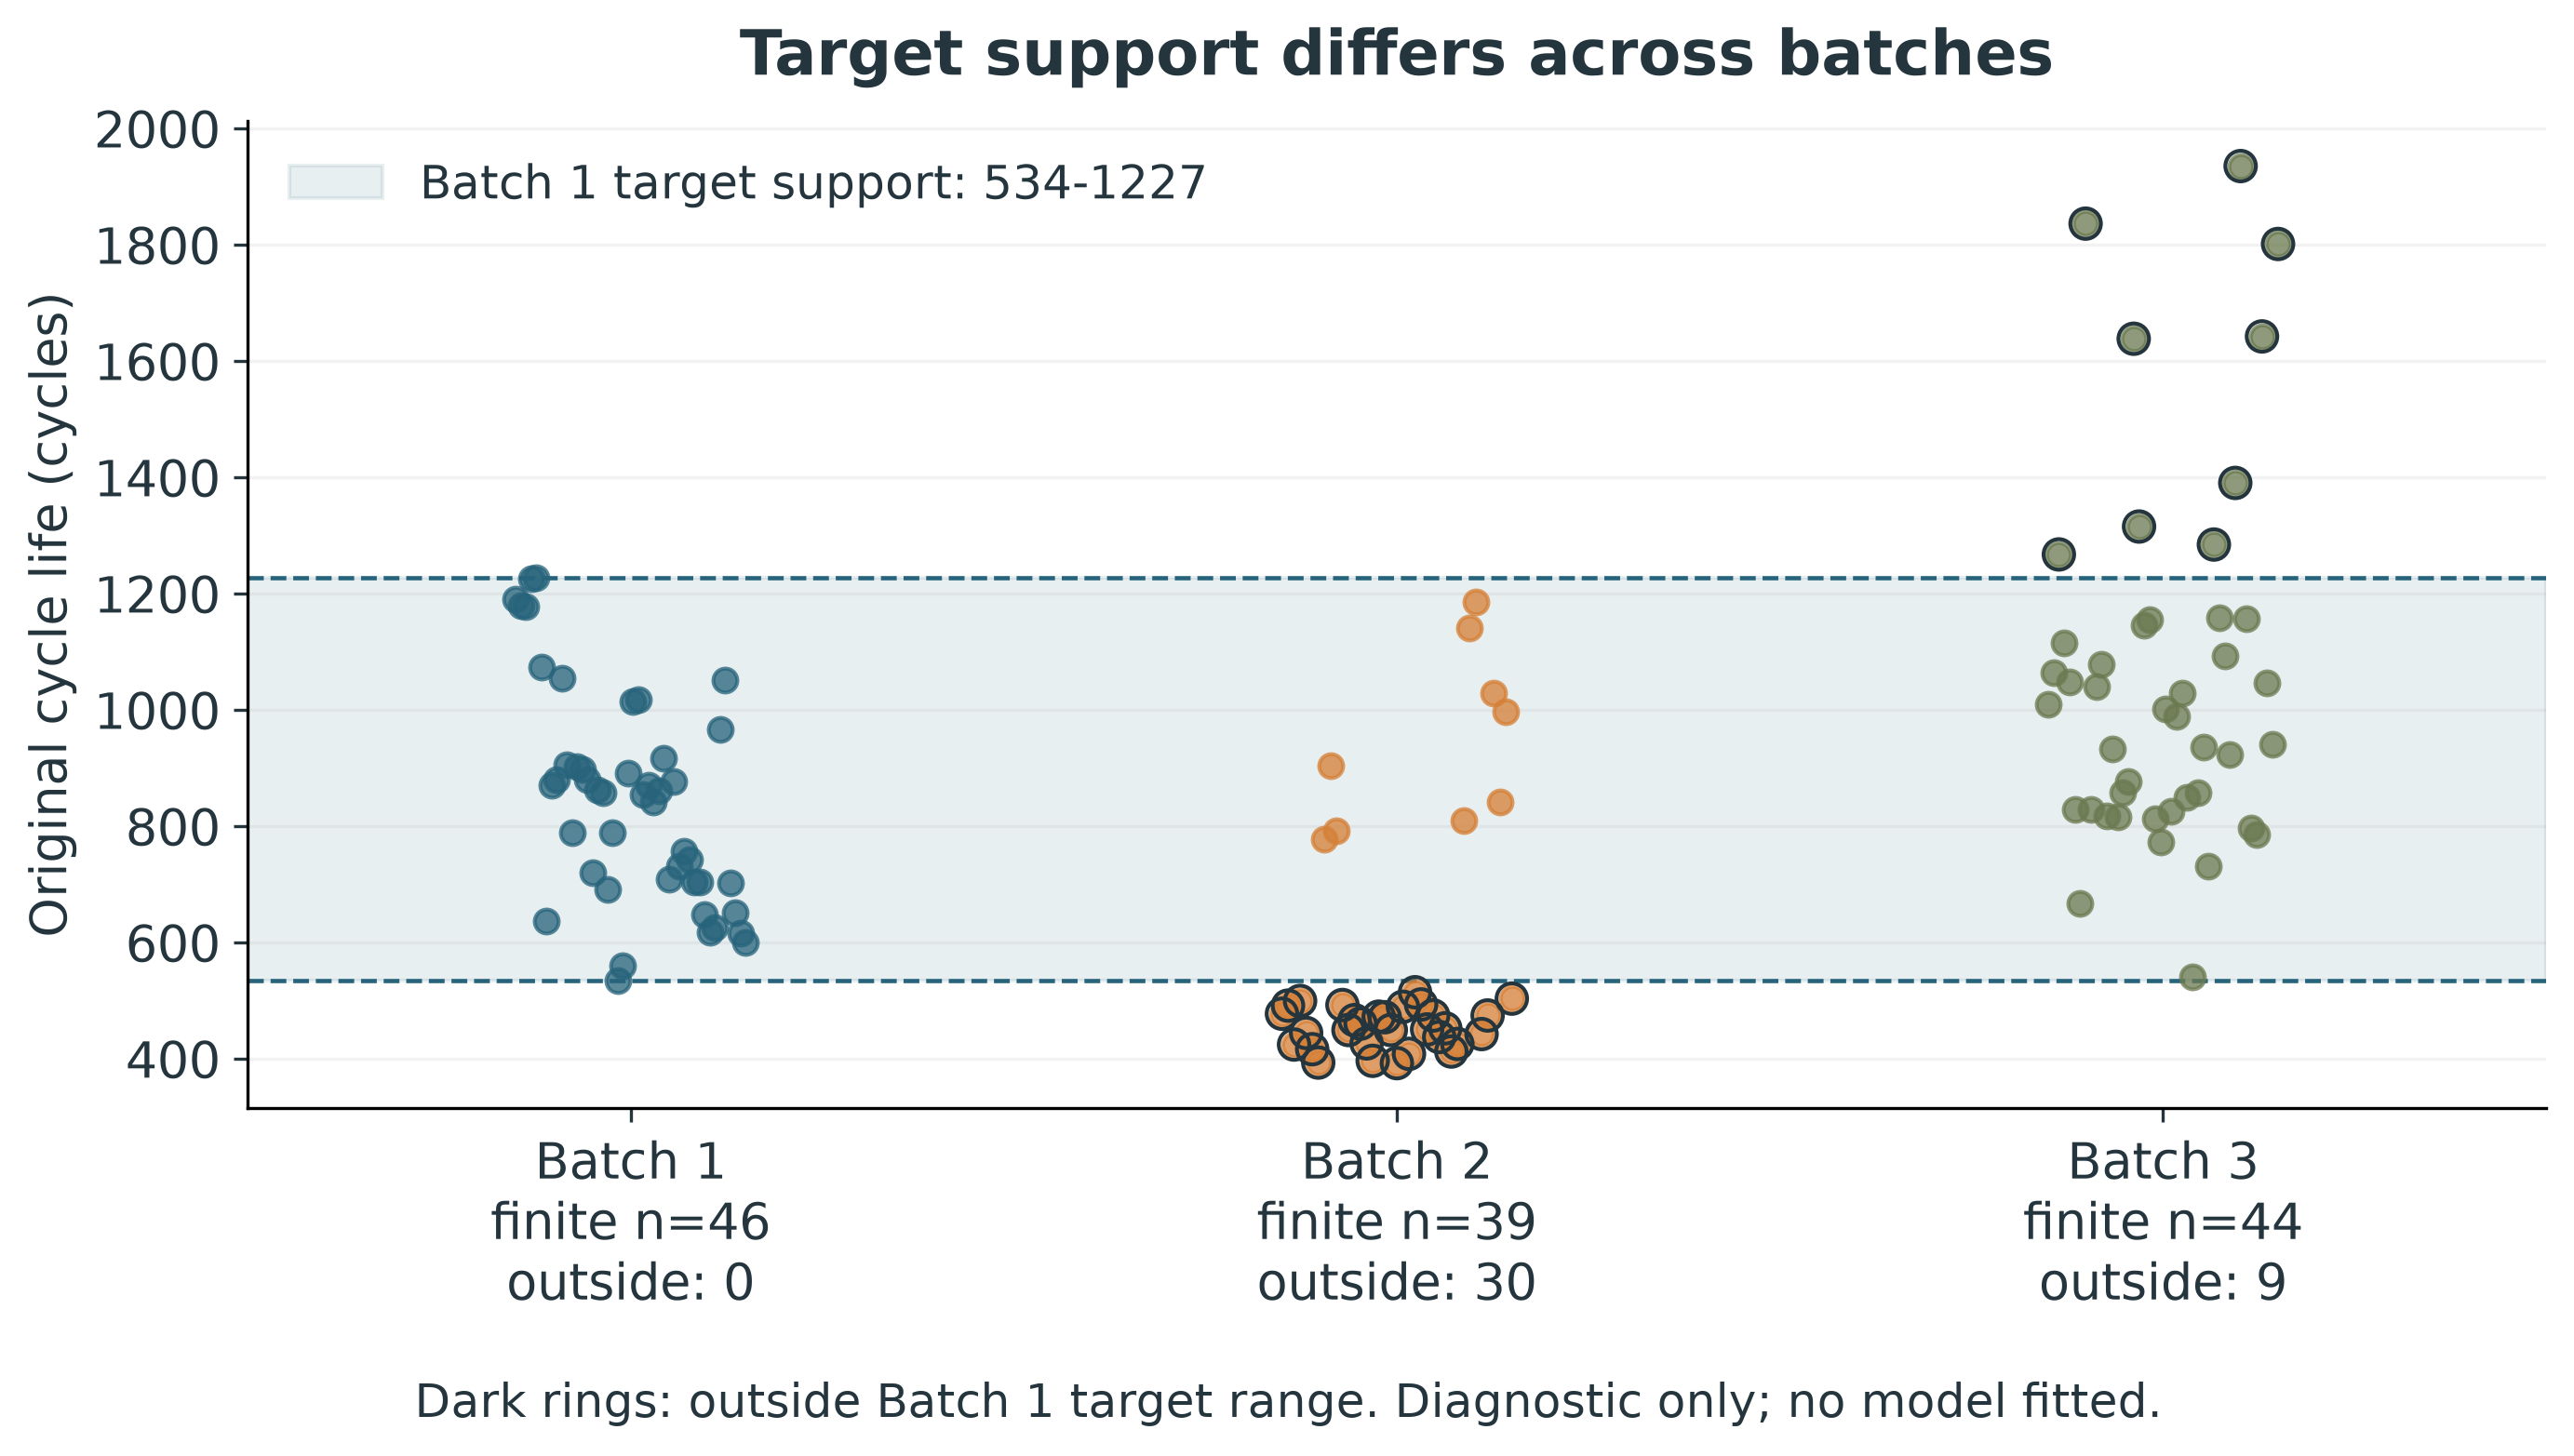

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


{'purpose': 'Report readability views of executed Q4/Q5 exploratory results',
 'new_model_fitting': False,
 'source_results': ['q1_q4_results.json', 'q3_q5_results.json'],
 'figures': ['q2_report_degradation.png',
  'q4_report_current_patterns.png',
  'q4_report_current_life.png',
  'q4_report_current_slope.png',
  'q5_report_redundancy.png',
  'q5_report_correlations.png']}

In [10]:
from src.eda_tree_constraints import run as run_tree_constraints
from src.eda_report_figures import run as run_report_views
tree_constraints = run_tree_constraints(PROJECT_ROOT)
display(tree_constraints['batch_statistics'])
show_figure('model_target_range.png')
report_views = run_report_views(PROJECT_ROOT)
display(report_views)


## 7. EDA에서 선형·규제 회귀 전략으로

첫 100사이클 → 원본 최종 Cycle Life 회귀를 유지한다. MAPE를 주 지표로 계획한다.
사용자 최신 결정에 따라 단순 선형회귀를 기준 모델, Ridge와 Elastic Net을 주요 후보로 한다.
최적 모델은 Batch 1 개발 검증으로 결정하며 현재 학습 성능은 없다.

- ΔQ log분산의 강한 신호: 핵심 신호만 쓰는 입력과 확장 입력을 비교한다.
- 정확한 중복과 높은 상관: 중복 조합을 피하고 Ridge의 L2, Elastic Net의 L1/L2 규제를 검토한다.
- 작은 개발 표본 46셀: 적은 피처와 규제로 계수 안정성을 관리한다.
- 정책 정보: C1·전환 SOC·C2의 수치 피처 후보를 검토하고 원문 정책은 그룹 기준으로 보존한다.
- 온도·IR·충전시간: 품질·단위를 검토한 후 추가 채택을 결정한다.
- 수명 범위 차이: 선형식은 범위 밖 값을 출력할 수 있지만 배치 간 관계의 유지가 필요하다.

Batch 1에서 Hold-out을 먼저 분리하고 개발 CV로 피처·규제 강도를 선택한다.
같은 셀을 분리하지 않으며 프로토콜 일반화를 평가하려면 CV와 Hold-out에 그룹 기준을 검토한다.
결측 처리·피처 선택·표준화는 fold train에서만 fit하고 검증/테스트에는 transform만 적용한다.
표준화는 단위를 맞추는 작업이며 수명 분포 차이·대표성 부족·피처-수명 관계 차이를 해소하지 않는다.
Batch 2·3은 과제 EDA에서 관찰했음을 명시하고 모델 선택·튜닝에는 사용하지 않는다.

논문은 Elastic Net으로 log cycle_life를 예측했으며, 공식 분할은 Batch 1·2 셀을 함께
학습/1차 테스트로 나눈다. 현재 과제 분할과 파일이 달라 동일 성능을 기대할 근거는 없다.
현재 Batch 2는 2018-02-20이고 공식 LoadData.m은 2017-06-30이므로 파일·수명 정의 확인이 필요하다.
타깃 로그 변환, 최종 피처, 분할 비율·fold·seed, 규제 탐색 범위·Optuna 예산은 착수 전 사용자와 확정한다.

참고: [Linear Models](https://scikit-learn.org/stable/modules/linear_model.html),
[StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html),
[공식 분할 코드](https://github.com/rdbraatz/data-driven-prediction-of-battery-cycle-life-before-capacity-degradation/blob/master/Load%20Data.ipynb).


In [2]:
source_files = [PROJECT_ROOT / 'src' / name for name in
                ('data.py','eda_distribution_protocol.py','eda_degradation.py','eda_early_signals.py','eda_tree_constraints.py','eda_report_figures.py')]
manifest = {
    'scope':'DAY 1 EDA and model design only',
    'student':'울산 3반 이웅희',
    'target':'original cycle_life, regression',
    'observation_limit_cycle':100,
    'source_snapshot':'configs/data-snapshot.json',
    'source_hashes':{str(path.relative_to(PROJECT_ROOT)):hashlib.sha256(path.read_bytes()).hexdigest()
                     for path in source_files},
    'environment':json.loads((PROJECT_ROOT / 'configs/environment.json').read_text()),
    'hypothesis_test':'Batch2 Welch primary and exact permutation supplementary, two-sided alpha=0.05',
    'random_sampling_used':False,
    'no_model_performance_reported':True,
    'model_direction':'Linear regression baseline; Ridge and Elastic Net with fold-local standardization',
}
(OUT / 'analysis-run.json').write_text(json.dumps(manifest, ensure_ascii=False, indent=2)+'\n')
display(manifest)

{'scope': 'DAY 1 EDA and model design only',
 'student': '울산 3반 이웅희',
 'target': 'original cycle_life, regression',
 'observation_limit_cycle': 100,
 'source_snapshot': 'configs/data-snapshot.json',
 'source_hashes': {'src/data.py': '01b20861c550cd8089cce85e9fc1ceb676b90ba54e3d23b40f370ada9337ced1',
  'src/eda_distribution_protocol.py': '8497cc5d472ab06f6f730b9906662f955196d62c653e351444aad67992b196ac',
  'src/eda_degradation.py': 'e7bbf2f359252fdba4dad20ff81fa6194129cc03029b3c669a3074b91914620d',
  'src/eda_early_signals.py': '26c283f401bde4dd616da576c781752804d329163e2ca9e56f3672c7e69c508f',
  'src/eda_tree_constraints.py': '4ebebf0c412f6aa78ca39e97f9cdcb59ce1d1f4fad83878dde3c5c735412c478',
  'src/eda_report_figures.py': 'a28fae9c1018af6fccc7a580544c33865738cbfa447dc430b65bf9992f1c9b27'},
 'environment': {'recorded_on': '2026-10-01',
  'timezone': 'Asia/Seoul',
  'python': '3.12.13',
  'executable': '/Users/lwh/Desktop/battery-project/.venv/bin/python',
  'uv': '0.12.19',
  'platform